In [1]:
import matplotlib.pyplot as plt 
import json
from glob import glob

from collections import defaultdict
import os
import numpy as np

import pandas as pd


dataset_names=[	    
        'adult',
	    'electricity',
	    'forest_cover',
	    'hyperplane_high_gradual_drift',
	    'insects',
	    'movingRBF',
	    'moving_squares',
	    'new_airlines',
	    'sea_high_abrupt_drift',
	    'sea_high_mixed_drift',
	    'shuttle',
	    'synth_RandomRBFDrift',
	    'synth_agrawal',
	    'vehicle_sensIT',
        'rialto',
        'weather',
        'river_Waveform_2',
        'river_anomalysine',
        'river_Waveform',
        'skmul_aggrawal',
        'skmul_anomalysine_2',
        'river_hyperlane_2',
        'skmul_anomalysine',
        'river_hyperlane',
        'skmul_hyperlane',
        'river_led',
        'skmul_ledgenerator',
        'river_led_default_drift',
        'skmul_ledgenerator_default_drift',
        'river_mixed',
        'skmul_randomRBF_default_drift',
        'river_SEA_2',
        'skmul_randomRBF_gradual',
        'skmul_randomTree_2',
        'river_randomRBF_2',
        'skmul_randomTree',
        'river_randomRBF',
        'river_randomRBF_drift',
        'skmul_SEA_2',
        'river_randomTree_2',
        'skmul_SEA',
        'river_randomTree',
        'skmul_Sine',
        'river_SEA',
        'skmul_STAGGER_2',
        'river_SINE',
        'skmul_STAGGER',
        'river_STAGGER',
        'skmul_Waveform',
        'river_aggrawal'

]


model_names=('AutoClass', 'AutoStreamML', 'ChaCha', 'EvoAutoML','OnlineAutoML', 'ARFC', 'HATC', 'SRPC'   )


dataset_by_model={}
for dataset in dataset_names:
    dataset_by_model[dataset]={}

for model in model_names:
    for dataset in dataset_names:
        dataset_by_model[dataset][model]=glob(f'./experiment-results/{model}/{model}_{dataset}*')

In [2]:
from utils import downsample, kappa_chan_probs, kappa_no_chan_probs

In [3]:
real_datasets=[
    'adult',
    'electricity',
    'forest_cover',
    'insects',
   	'new_airlines',
    'shuttle',
    'vehicle_sensIT',
    'rialto',
    'weather',
]

A_drift=[
    'skmul_ledgenerator', #20/1
    'river_SEA_2', #15/1
    'skmul_randomTree', #15/1
    'river_randomTree', #30/1
    'river_SINE', #25/1
    'river_Waveform', #27/1
    'river_STAGGER', #25/1
    'river_mixed' #20
]

I_drift=[
    'synth_RandomRBFDrift',
    'river_randomRBF_drift',
    'movingRBF'
]

G_drift = [
    'river_SEA',  #20/2
    'river_Waveform_2', #23/10
    'river_hyperlane', #20/2
    'river_hyperlane_2', #20/20
    'river_led', #20/2
    'river_randomRBF', #25/4
    'river_randomRBF_2', #19/10
    'river_randomTree_2', #12/9
    'skmul_SEA_2', #20/10
    'skmul_STAGGER', #25/5
    'skmul_STAGGER_2', #15/15
    'skmul_anomalysine', #15/5
    'skmul_anomalysine_2', #10/10
    'skmul_randomRBF_gradual', #15/15
    'skmul_randomTree_2', #12/9
 ]

In [4]:
import json
import numpy as np
import matplotlib.pyplot as plt





def plot_drift(drift_case,type=None):
    colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd", "#8c564b", "#e377c2",'#8e44ad']
    
    default_config=True
    
    fig, axes = plt.subplots(1, 2, figsize=(35, 13))

    
    dataset_list=drift_case
    
    for model, color in zip(model_names, colors):
        kappa_no_change_all = []
        kappa_chance_all = []
    
        for data_name in dataset_list:
            real_dataset = pd.read_csv(f'stream_datasets/{data_name}.csv')
            class_values = real_dataset['class']
            window_size = 1000 # if len(class_values) < 105000 else 10000
            threshold = int(len(class_values) - window_size)
            class_values = class_values[:threshold]
    
            no_change_probabilities = kappa_no_chan_probs(window_size=window_size, class_values=class_values)
            chance_probabilities = kappa_chan_probs(window_size=window_size, class_values=class_values)
    
            for sample in dataset_by_model[data_name][model]:
                # filter configs
                if default_config:
                    if model=='AutoClass' and 'population_size_10_exploration_window_1000' not in sample: continue
                    if model=='AutoStreamML' and 'exploration_window_1000_ensemble_size_3_budget_10' not in sample: continue
                    if model=='EvoAutoML' and 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample: continue
                    if model=='OnlineAutoML' and 'default' not in sample: continue
                    if model in ['SRPC','ARFC','HATC'] and 'nmodel_3' not in sample: continue
    
                with open(sample) as f:
                    data = json.load(f)
    
                prequential_scores = np.array(data['prequential_scores'])
                if len(prequential_scores) < threshold:
                    continue
                prequential_scores = prequential_scores[:threshold]
                prequential_scores = downsample(prequential_scores, window_size)
    
                # compute kappas for THIS run
                kappa_nc = (prequential_scores - no_change_probabilities) / (1 - no_change_probabilities)
                kappa_ch = (prequential_scores - chance_probabilities) / (1 - chance_probabilities)
    
                kappa_no_change_all.append(kappa_nc)
                kappa_chance_all.append(kappa_ch)
    
        # pad all runs to same length
        max_len = max(len(s) for s in kappa_no_change_all)
        def pad(arr_list):
            arr = np.full((len(arr_list), max_len), np.nan)
            for i, s in enumerate(arr_list):
                arr[i, :len(s)] = s
            return arr
    
        kappa_nc_arr = pad(kappa_no_change_all)
        kappa_ch_arr = pad(kappa_chance_all)
    
        # mean & std
        mean_nc, std_nc = np.nanmean(kappa_nc_arr, axis=0), np.nanstd(kappa_nc_arr, axis=0)
        mean_ch, std_ch = np.nanmean(kappa_ch_arr, axis=0), np.nanstd(kappa_ch_arr, axis=0)
    
        x = np.arange(len(mean_nc)) * window_size
        short_name = {
            'OnlineAutoML': 'OnlineAutoML',
            'AutoClass': 'AutoClass',
            'AutoStreamML': 'ASML',
            'EvoAutoML': 'EvoAutoML'
        }.get(model, model)

        if type == "G":
            fig.suptitle("Gradual Drift", fontsize=40)
            lines=[20000,10000,19000,23000]
            for pos in lines:
                axes[0].axvline(pos, color="black", linestyle="--", linewidth=3)
                axes[1].axvline(pos, color="black", linestyle="--", linewidth=3)

        elif type == "A":
            fig.suptitle("Abrupt Drift", fontsize=40)
            lines=[20000,15000,30000,25000,27000]
            for pos in lines:
                axes[0].axvline(pos, color="black", linestyle="--", linewidth=3)
                axes[1].axvline(pos, color="black", linestyle="--", linewidth=3)
        else:
            fig.suptitle("Incremental Drift", fontsize=40)
    
        axes[0].plot(x, mean_nc, color=color, linewidth=4, label=short_name)
        # axes[0].set_ylim(-2, 2)
        # axes[0].fill_between(x, mean_nc-std_nc, mean_nc+std_nc, color=color, alpha=0.2)

#         axes[0].plot(
#     x, mean_nc - std_nc,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
#         axes[0].plot(
#     x, mean_nc + std_nc,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
    
        axes[1].plot(x, mean_ch, color=color, linewidth=4, label=short_name)
        # axes[1].ylim(-2,2)
        # axes[1].fill_between(x, mean_ch-std_ch, mean_ch+std_ch, color=color, alpha=0.2)

#         axes[1].plot(
#     x, mean_ch - std_ch,
#     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
#         axes[1].plot(
#                     x, mean_ch + std_ch,
#                     color=color, linestyle='--', linewidth=1, alpha=0.8
# )
        # std_kwargs = dict(
        # linestyle=(0, (5, 2)),  # long dash, short gap
        # linewidth=1.4,
        # alpha=0.9
        # )
        
        # axes[0].plot(x, mean_nc - std_nc, color=color, **std_kwargs)
        # axes[0].plot(x, mean_nc + std_nc, color=color, **std_kwargs)
        
        # axes[1].plot(x, mean_ch - std_ch, color=color, **std_kwargs)
        # axes[1].plot(x, mean_ch + std_ch, color=color, **std_kwargs)
    
    for i, title in enumerate(["$\kappa^+$", "$\kappa$"]):
        axes[i].set_xlabel("Instance number", fontsize=30)
        axes[i].set_ylabel(title, fontsize=30)
        axes[i].tick_params(axis='both', labelsize=30)
        axes[i].grid(True, color='0.8' ,alpha=1.0, linewidth=2.5)

    
    # fig.legend(loc="lower center", ncol=5, fontsize=25, bbox_to_anchor=(0.5, -0.17))
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=8, fontsize=25, bbox_to_anchor=(0.5, -0.1))
    plt.tight_layout()
    plt.show()




# Old Visuals

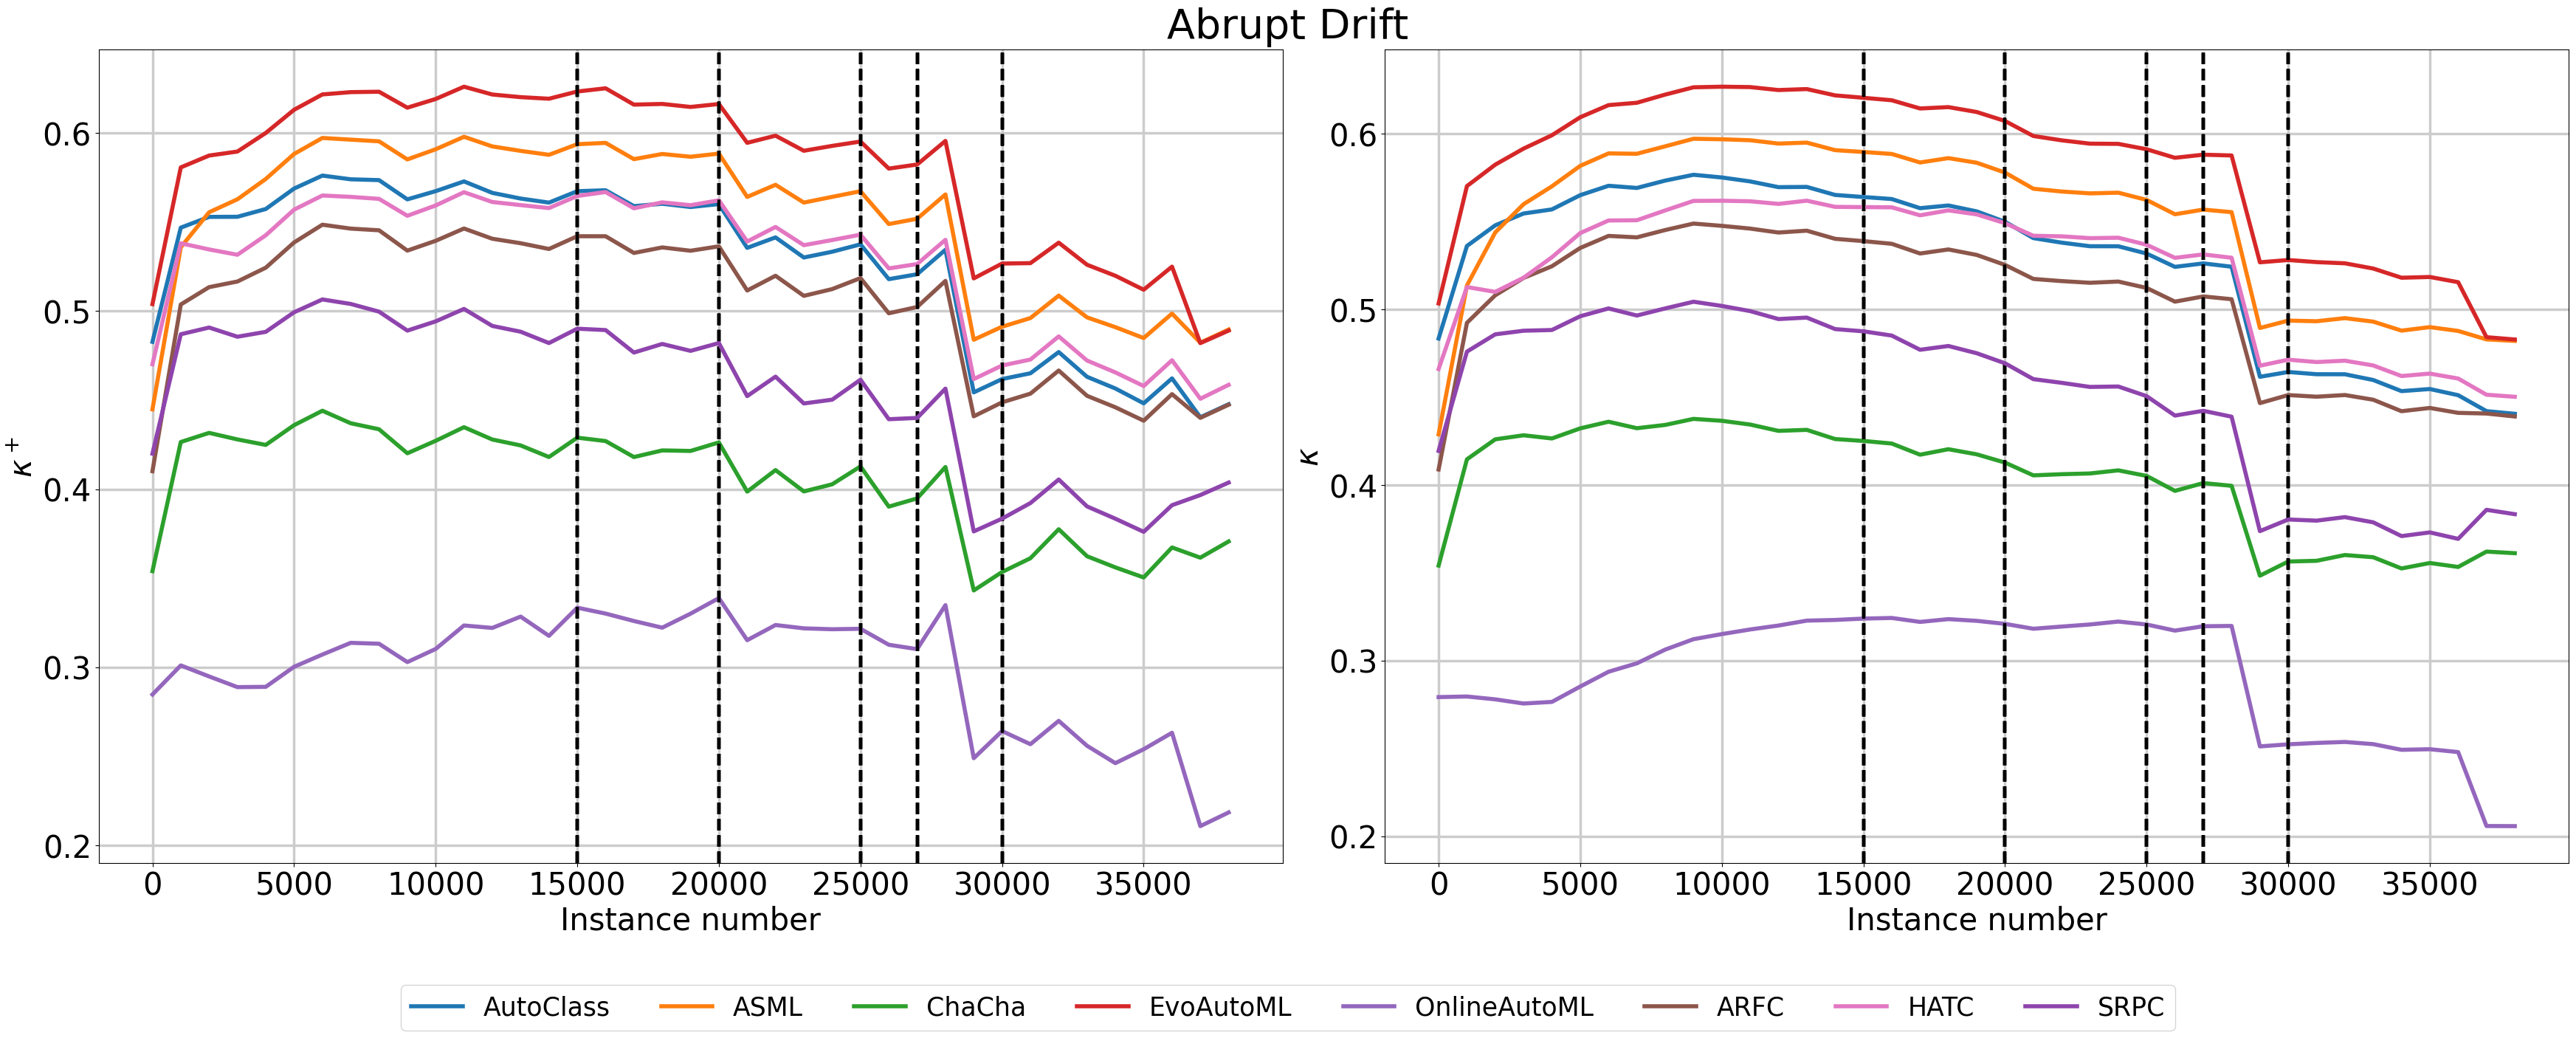

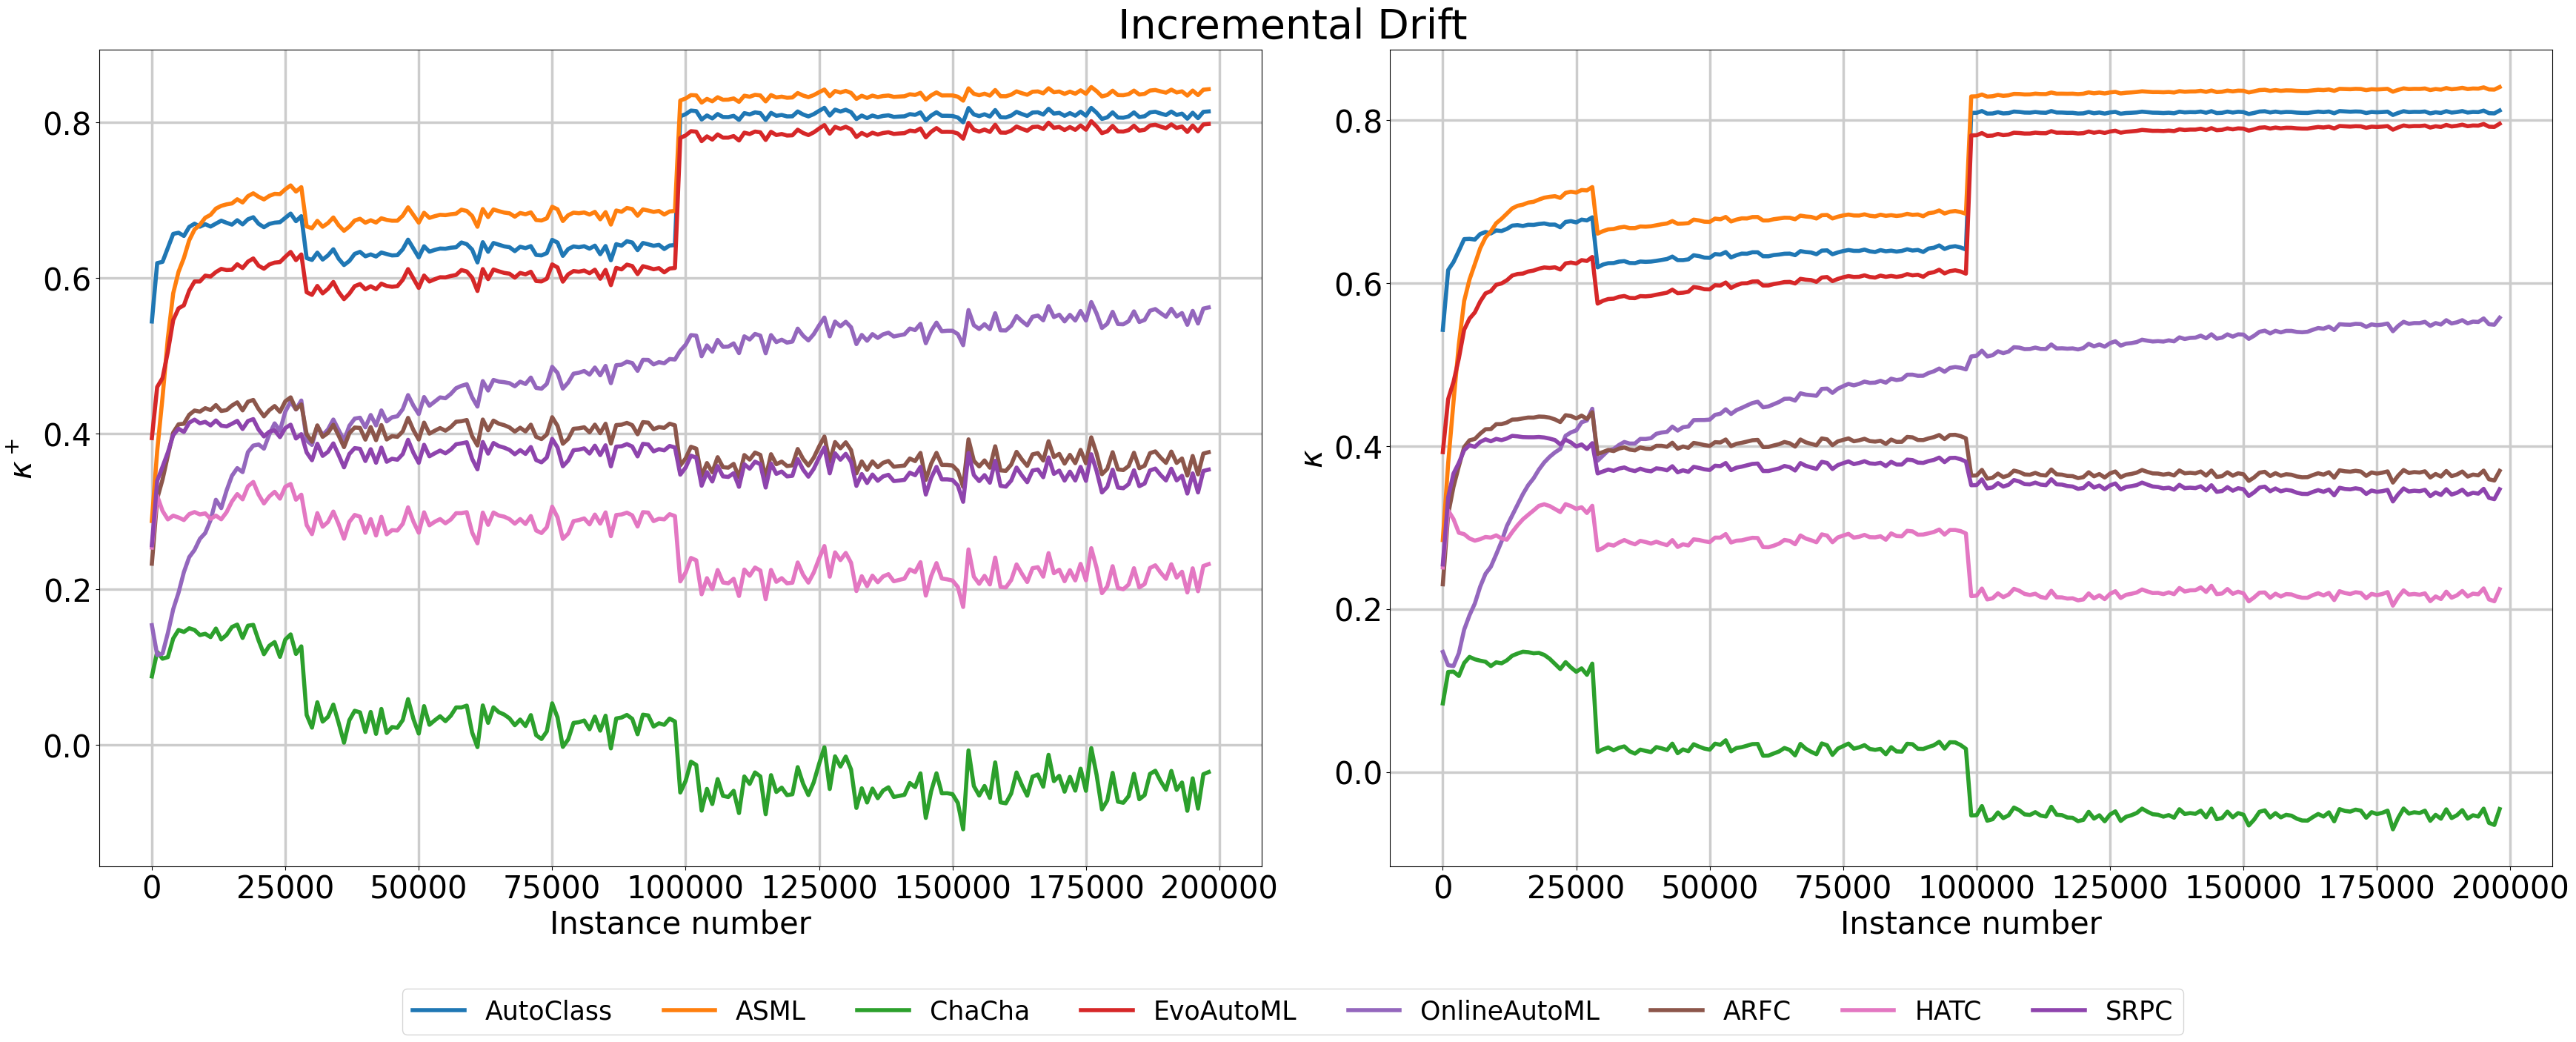

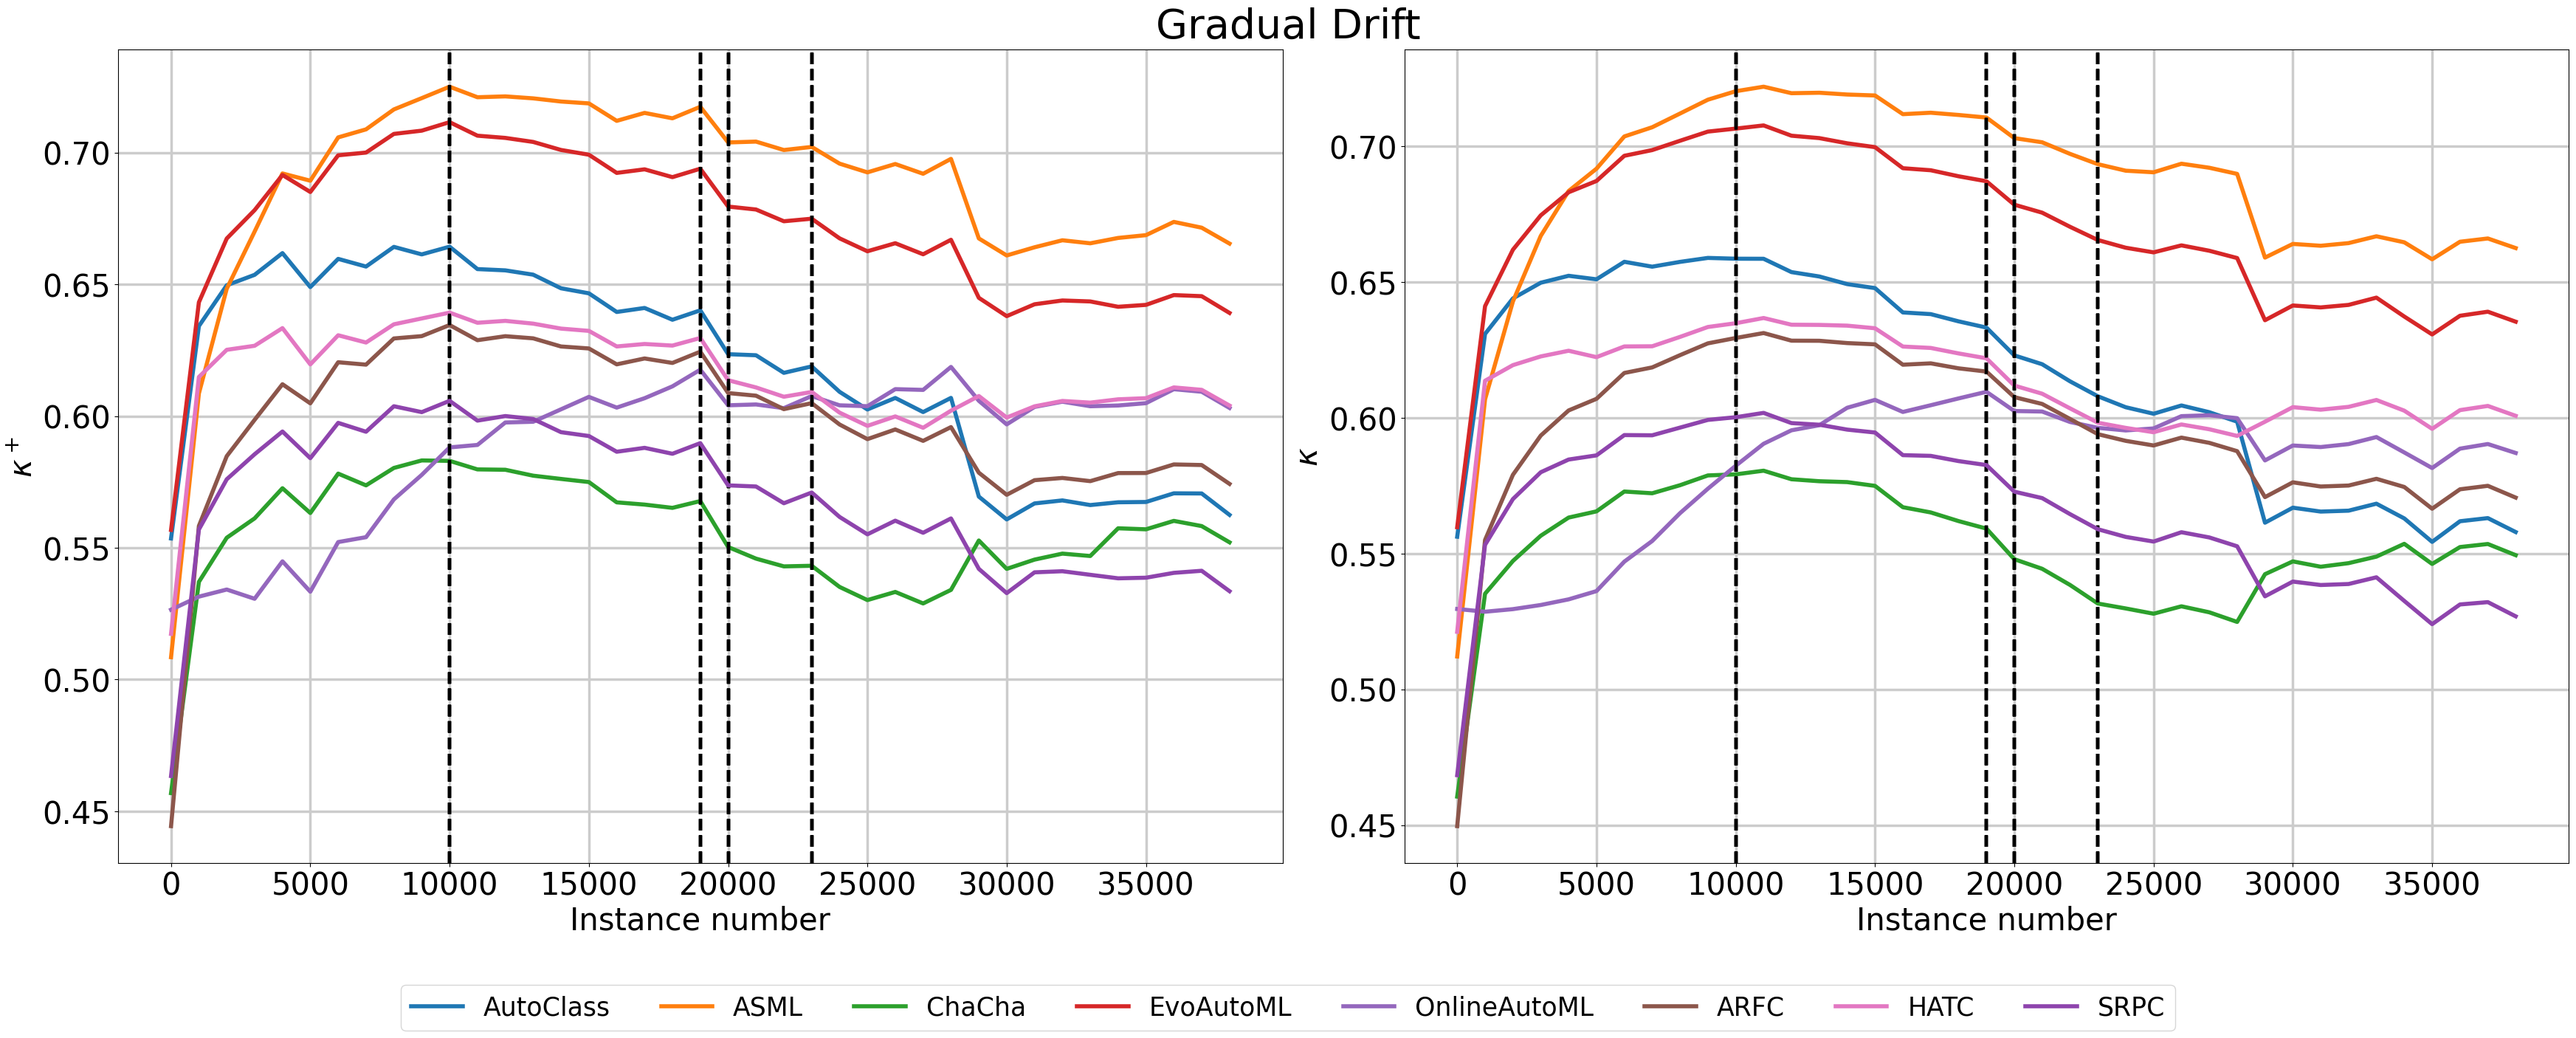

In [5]:
plot_drift(A_drift,'A')
plot_drift(I_drift)
plot_drift(G_drift,'G')

In [6]:
DRIFT_INFO = {
    # -------- Gradual --------
    'river_SEA':                 dict(type='G', point=20000, width=2000),
    'river_Waveform_2':          dict(type='G', point=23000, width=10000),
    'river_hyperlane':           dict(type='G', point=20000, width=2000),
    'river_hyperlane_2':         dict(type='G', point=20000, width=20000),
    'river_led':                 dict(type='G', point=20000, width=2000),
    'river_randomRBF':           dict(type='G', point=25000, width=4000),
    'river_randomRBF_2':         dict(type='G', point=19000, width=10000),
    'river_randomTree_2':        dict(type='G', point=12000, width=9000),
    'skmul_SEA_2':               dict(type='G', point=20000, width=10000),
    'skmul_STAGGER':             dict(type='G', point=25000, width=5000),
    'skmul_STAGGER_2':           dict(type='G', point=15000, width=15000),
    'skmul_anomalysine':         dict(type='G', point=15000, width=5000),
    'skmul_anomalysine_2':       dict(type='G', point=10000, width=10000),
    'skmul_randomRBF_gradual':   dict(type='G', point=15000, width=15000),
    'skmul_randomTree_2':        dict(type='G', point=12000, width=9000),

    # -------- Abrupt --------
    'skmul_ledgenerator':        dict(type='A', point=20000, width=1000),
    'river_SEA_2':               dict(type='A', point=15000, width=1000),
    'skmul_randomTree':          dict(type='A', point=15000, width=1000),
    'river_randomTree':          dict(type='A', point=30000, width=1000),
    'river_SINE':                dict(type='A', point=25000, width=1000),
    'river_Waveform':            dict(type='A', point=27000, width=1000),
    'river_STAGGER':             dict(type='A', point=25000, width=1000),
    'river_mixed':               dict(type='A', point=20000, width=1000),
}


In [7]:
import matplotlib as mpl

mpl.rcParams.update({
    "font.size": 18,          # base font size
    "axes.titlesize": 18,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 18,
    "figure.titlesize": 26,
})

In [8]:
from scipy.stats import rankdata
import numpy as np

def build_rank_heatmap(
    dataset_list,
    model_names,
    dataset_by_model,
    kappa_type="nc",        # "nc" or "ch"
    bin_size=1000,
    max_bins=20,
    window_size=100,
    default_config=True
):
    n_models = len(model_names)
    model_idx = {m: i for i, m in enumerate(model_names)}

    # heatmap_bins[bin][model] = list of κ values
    heatmap_bins = [
        [[] for _ in range(n_models)]
        for _ in range(max_bins)
    ]

    for dataset in dataset_list:
        if dataset in DRIFT_INFO:
            drift = DRIFT_INFO[dataset]
            start = drift['point'] + drift['width']
        else:
            start = 0

        real_dataset = pd.read_csv(f'stream_datasets/{dataset}.csv')
        class_values = real_dataset['class']

        threshold = int(len(class_values) - window_size)
        class_values = class_values[:threshold]

        no_change_probabilities = kappa_no_chan_probs(
            window_size=window_size,
            class_values=class_values
        )
        chance_probabilities = kappa_chan_probs(
            window_size=window_size,
            class_values=class_values
        )

        for model in model_names:
            for sample in dataset_by_model[dataset][model]:
                # filter configs
                if default_config:
                    if model=='AutoClass' and 'population_size_10_exploration_window_1000' not in sample: continue
                    if model=='AutoStreamML' and 'exploration_window_1000_ensemble_size_3_budget_10' not in sample: continue
                    if model=='EvoAutoML' and 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample: continue
                    if model=='OnlineAutoML' and 'default' not in sample: continue
                    if model in ['SRPC','ARFC','HATC'] and 'nmodel_3' not in sample: continue
    

                with open(sample) as f:
                    data = json.load(f)

                prequential_scores = np.array(data['prequential_scores'])
                if len(prequential_scores) < threshold:
                    continue

                prequential_scores = prequential_scores[:threshold]
                prequential_scores = downsample(prequential_scores, window_size)

                if kappa_type == "nc":
                    kappa = (
                    (prequential_scores - no_change_probabilities)
                    / (1 - no_change_probabilities)
                )
                elif kappa_type == "ch":
                    kappa = (
                    (prequential_scores - chance_probabilities)
                    / (1 - chance_probabilities)
                )
                elif kappa_type == "accuracy":
                    kappa = prequential_scores
                elif kappa_type == "energy":
                    metric = np.array(data["energy_consumed"])[:threshold]
                    metric = downsample(metric, window_size)
                    kappa = -metric  
                elif kappa_type == "time":
                    metric = np.array(data["time"])[:threshold]
                    metric = downsample(metric, window_size)
                    kappa = -metric  

                x = np.arange(len(kappa)) * window_size

                for t, val in zip(x, kappa):
                    if t < start:
                        continue
                    b = int((t - start) // bin_size)
                    if b >= max_bins:
                        break
                    heatmap_bins[b][model_idx[model]].append(val)

    # ---- convert to rank heatmap ----
    heatmap = np.full((n_models, max_bins), np.nan)

    for b in range(max_bins):
        means = np.array([
            np.mean(v) if len(v) > 0 else np.nan
            for v in heatmap_bins[b]
        ])

        if np.all(np.isnan(means)):
            continue

        # higher κ = better → rank 1 best
        ranks = rankdata(-means, method="average")
        heatmap[:, b] = ranks

    return heatmap


import matplotlib.pyplot as plt

def plot_rank_heatmap(
    heatmap,
    model_names,
    title,
    bin_size=1000
):
    n_models, n_bins = heatmap.shape
    heatmap = np.ma.masked_invalid(heatmap)

    display_names = {
        "AutoStreamML": "ASML"
    }

    y_labels = [
        display_names.get(m, m) for m in model_names
    ]

    fig, ax = plt.subplots(figsize=(17, 5.5),dpi=300)

    im = ax.imshow(
        heatmap,
        aspect="auto",
        cmap="RdBu_r",
        vmin=1,
        vmax=n_models
    )

    ax.set_yticks(range(n_models))
    ax.set_yticklabels(y_labels, fontsize=18)

    ax.set_xticks(range(n_bins))

    if bin_size < 1000:
            xticklabels = [
        f"{((i+1)*bin_size)/1000:.1f}k" for i in range(n_bins)
    ]
    else:
        xticklabels = [f"{(i+1)*bin_size//1000}k" for i in range(n_bins)]

    ax.set_xticklabels(xticklabels, fontsize=18)

    ax.set_xlabel("Instances since drift", fontsize=20)
    ax.set_title(title, fontsize=24)

    cbar = plt.colorbar(im, ax=ax)
    cbar.set_label("Mean rank (1 = best)", fontsize=20)

    plt.tight_layout()
    plt.show()



# Drift analysis

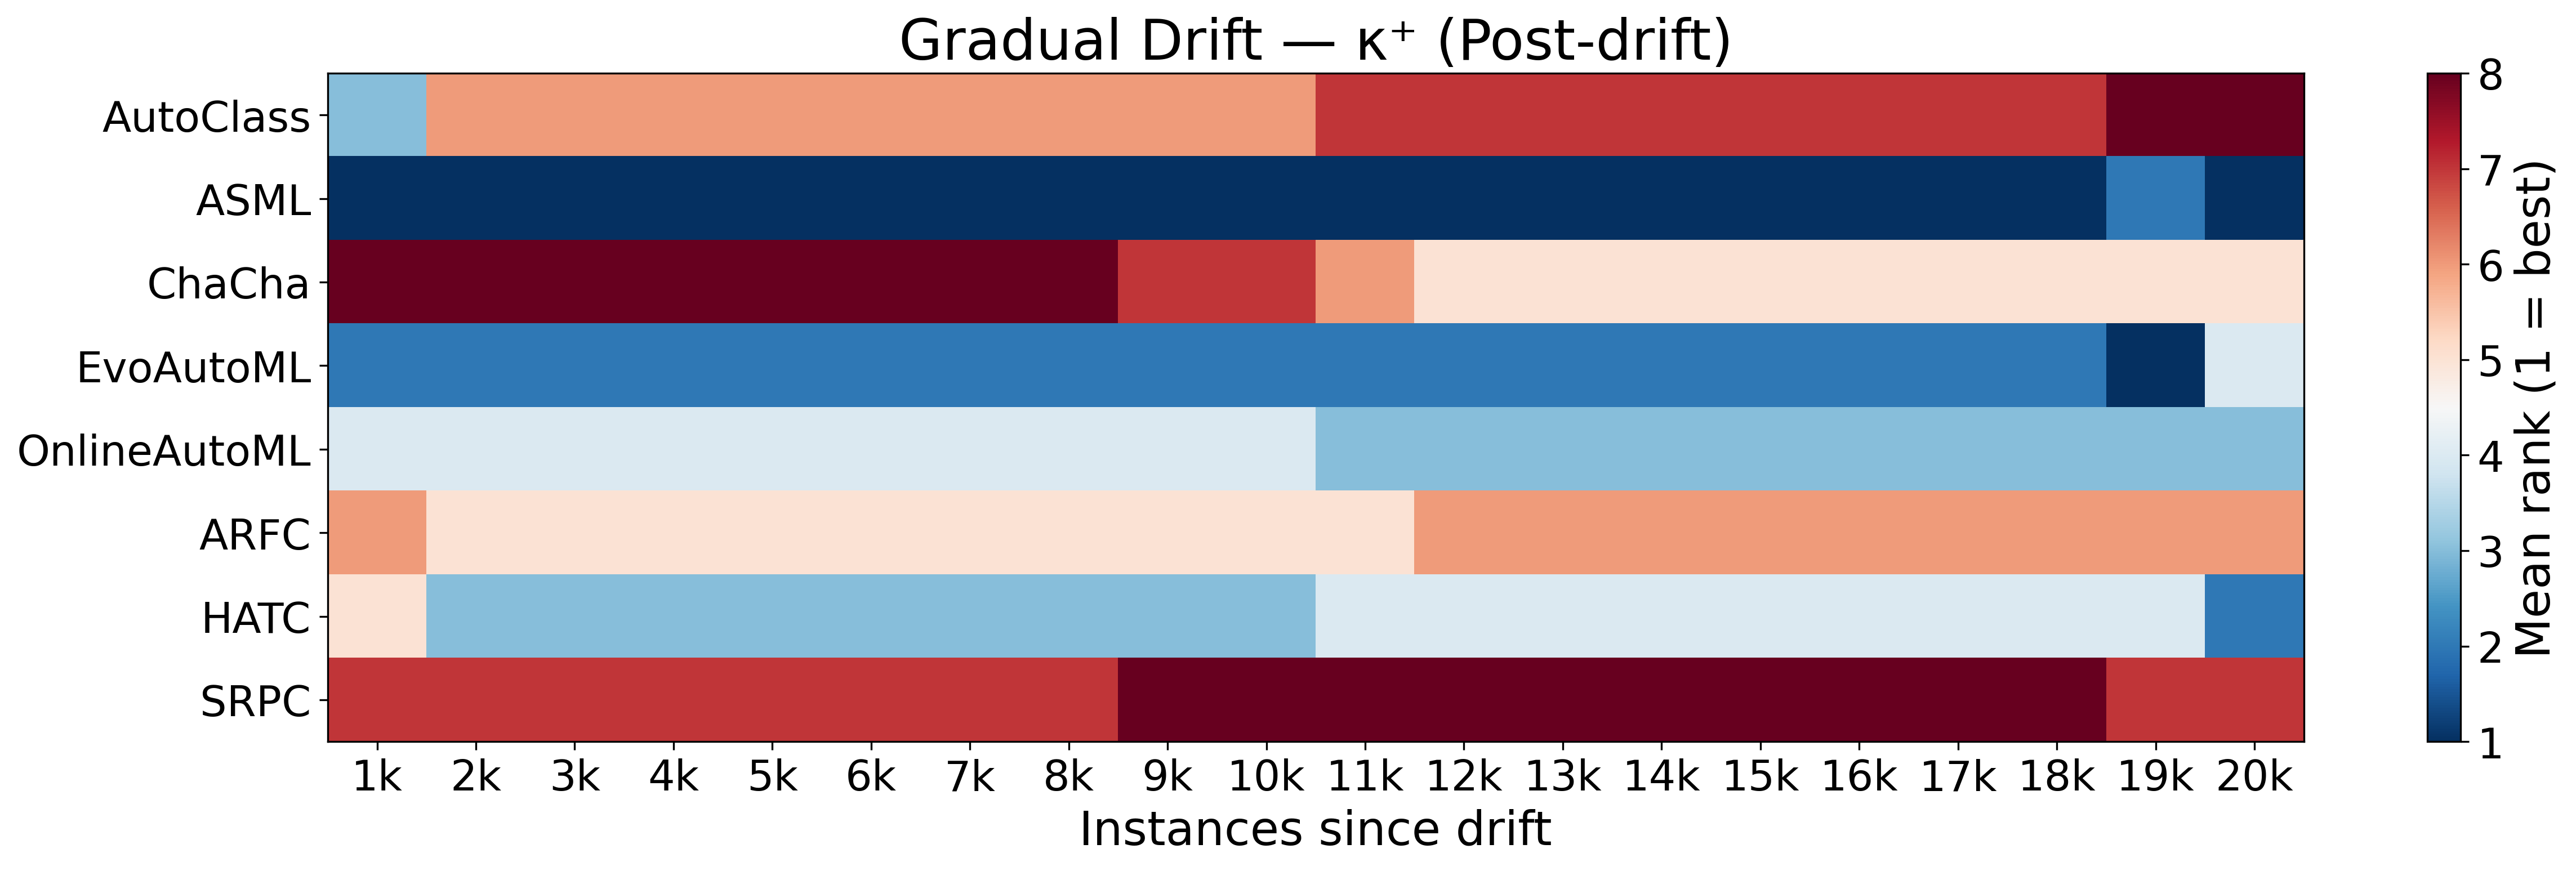

In [9]:
heatmap_g_nc = build_rank_heatmap(
    dataset_list=G_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="nc"
)




plot_rank_heatmap(
    heatmap_g_nc,
    model_names,
    title="Gradual Drift — κ⁺ (Post-drift)"
)


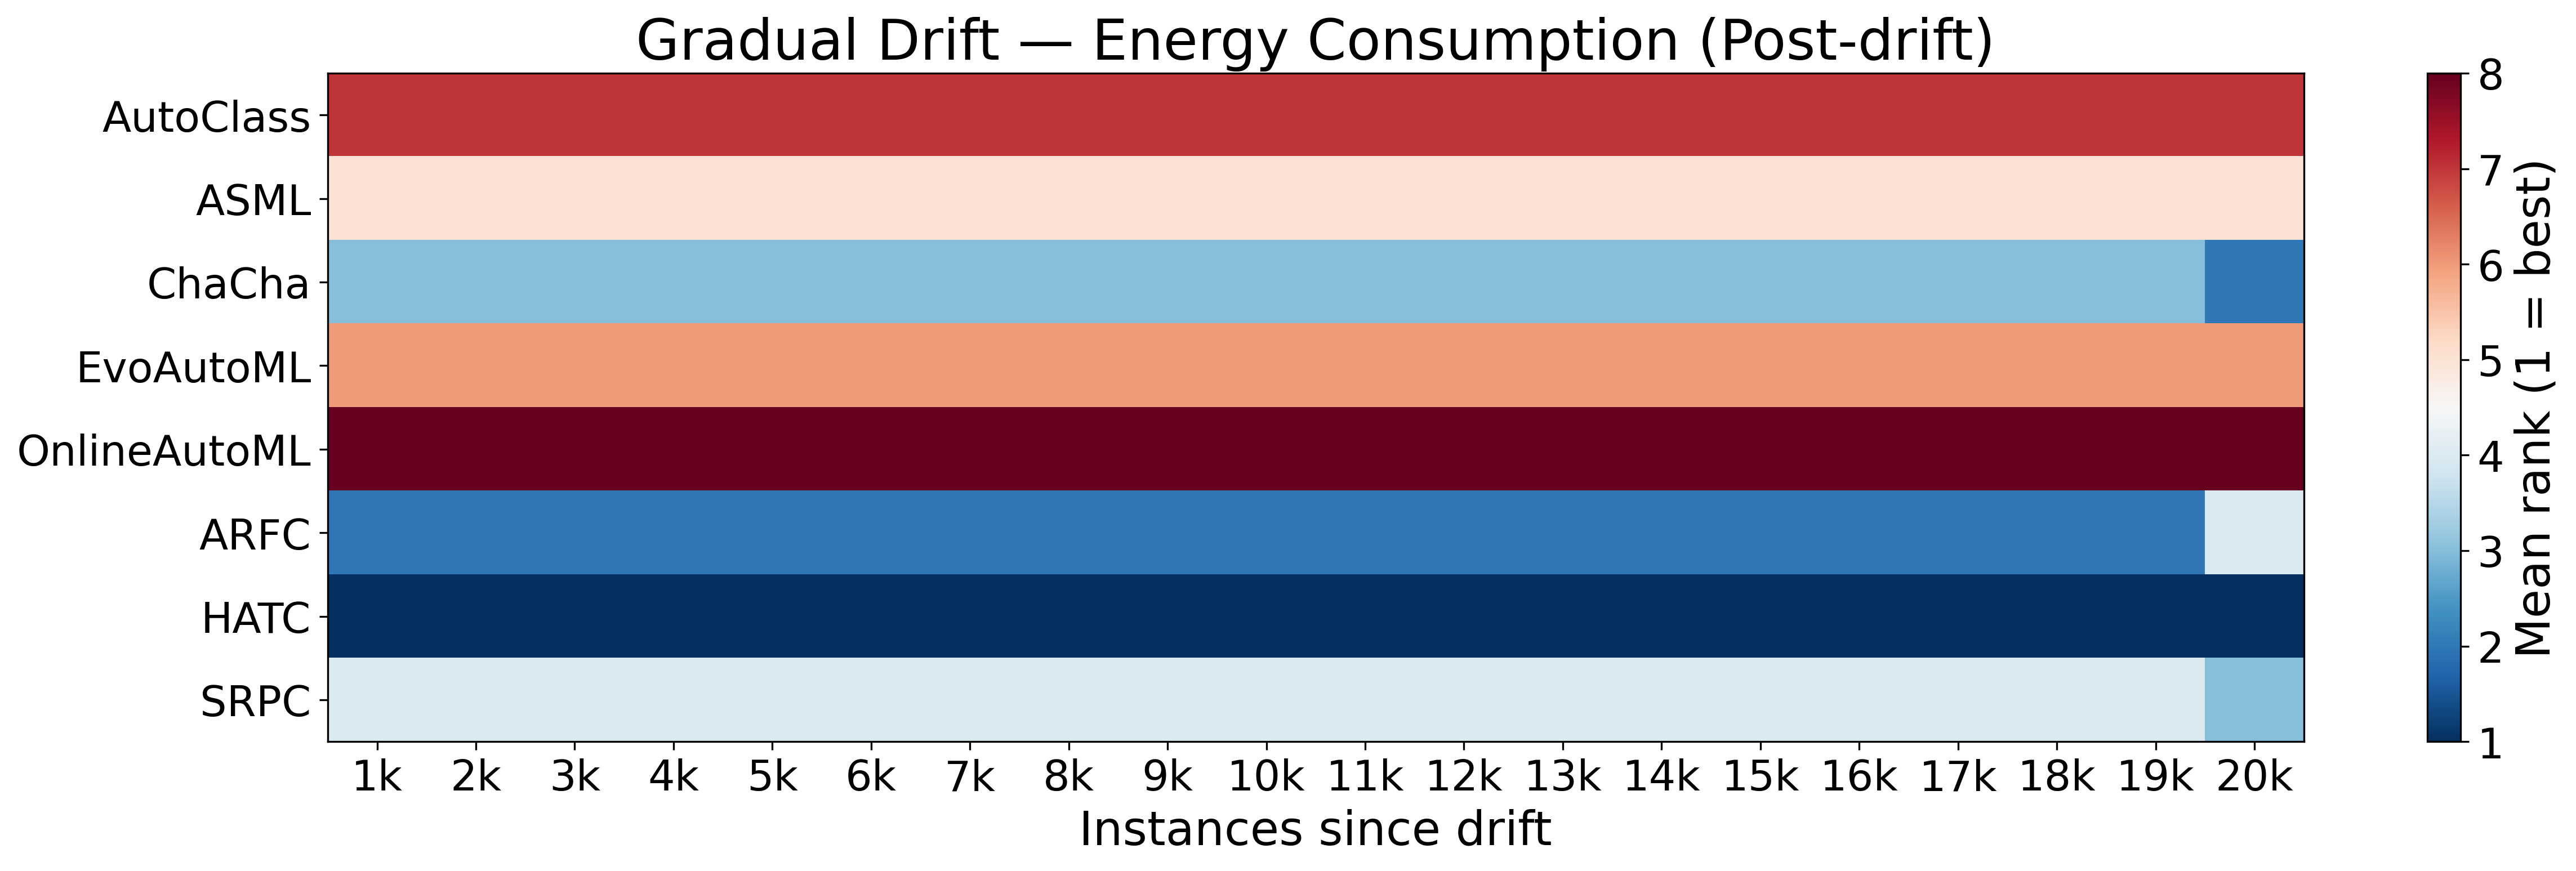

In [10]:
heatmap_g_energy = build_rank_heatmap(
    dataset_list=G_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="energy"
)




plot_rank_heatmap(
    heatmap_g_energy,
    model_names,
    title="Gradual Drift — Energy Consumption (Post-drift)"
)

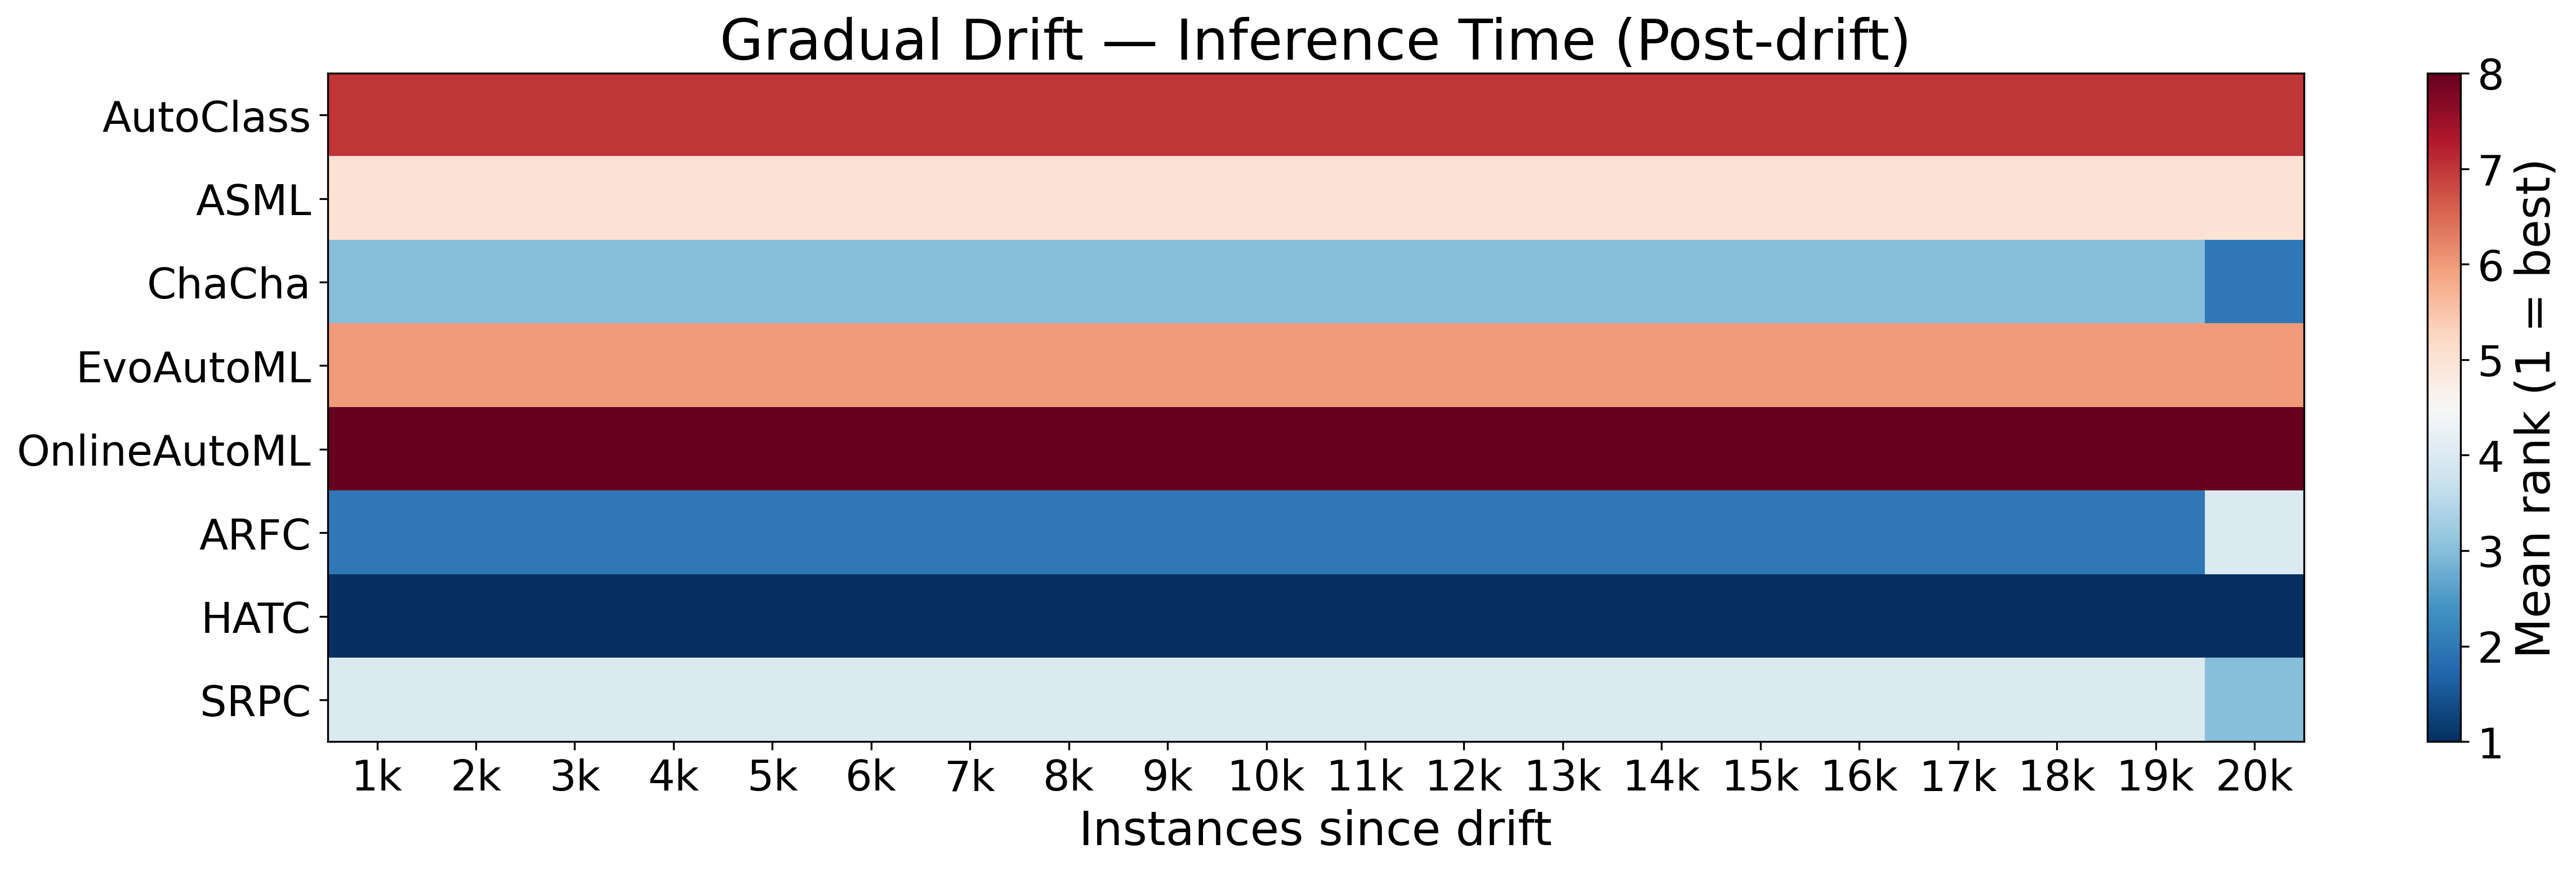

In [11]:
heatmap_g_energy = build_rank_heatmap(
    dataset_list=G_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="time"
)




plot_rank_heatmap(
    heatmap_g_energy,
    model_names,
    title="Gradual Drift — Inference Time (Post-drift)"
)

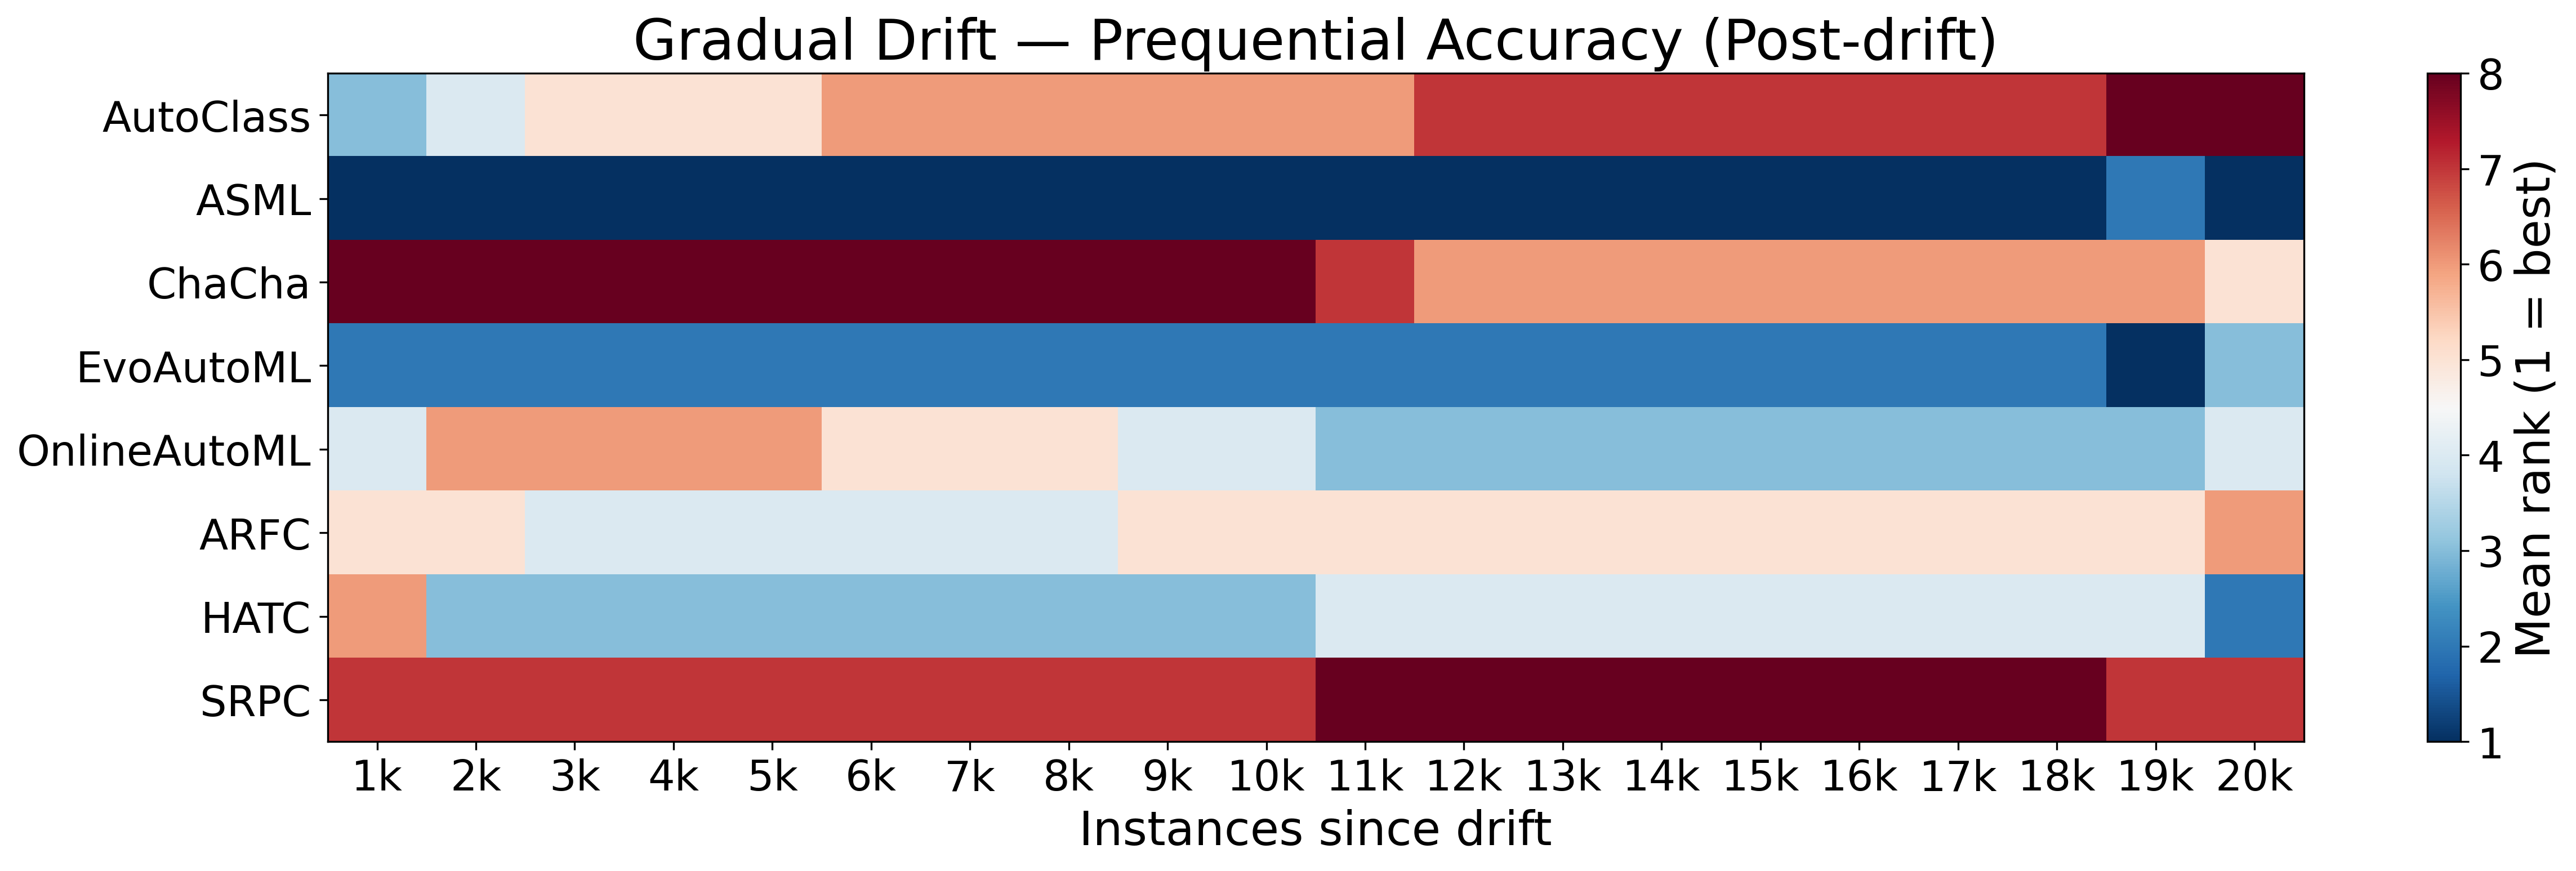

In [12]:
heatmap_g_acc = build_rank_heatmap(
    dataset_list=G_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="accuracy"
    
)




plot_rank_heatmap(
    heatmap_g_acc,
    model_names,
    title="Gradual Drift — Prequential Accuracy (Post-drift)"
)

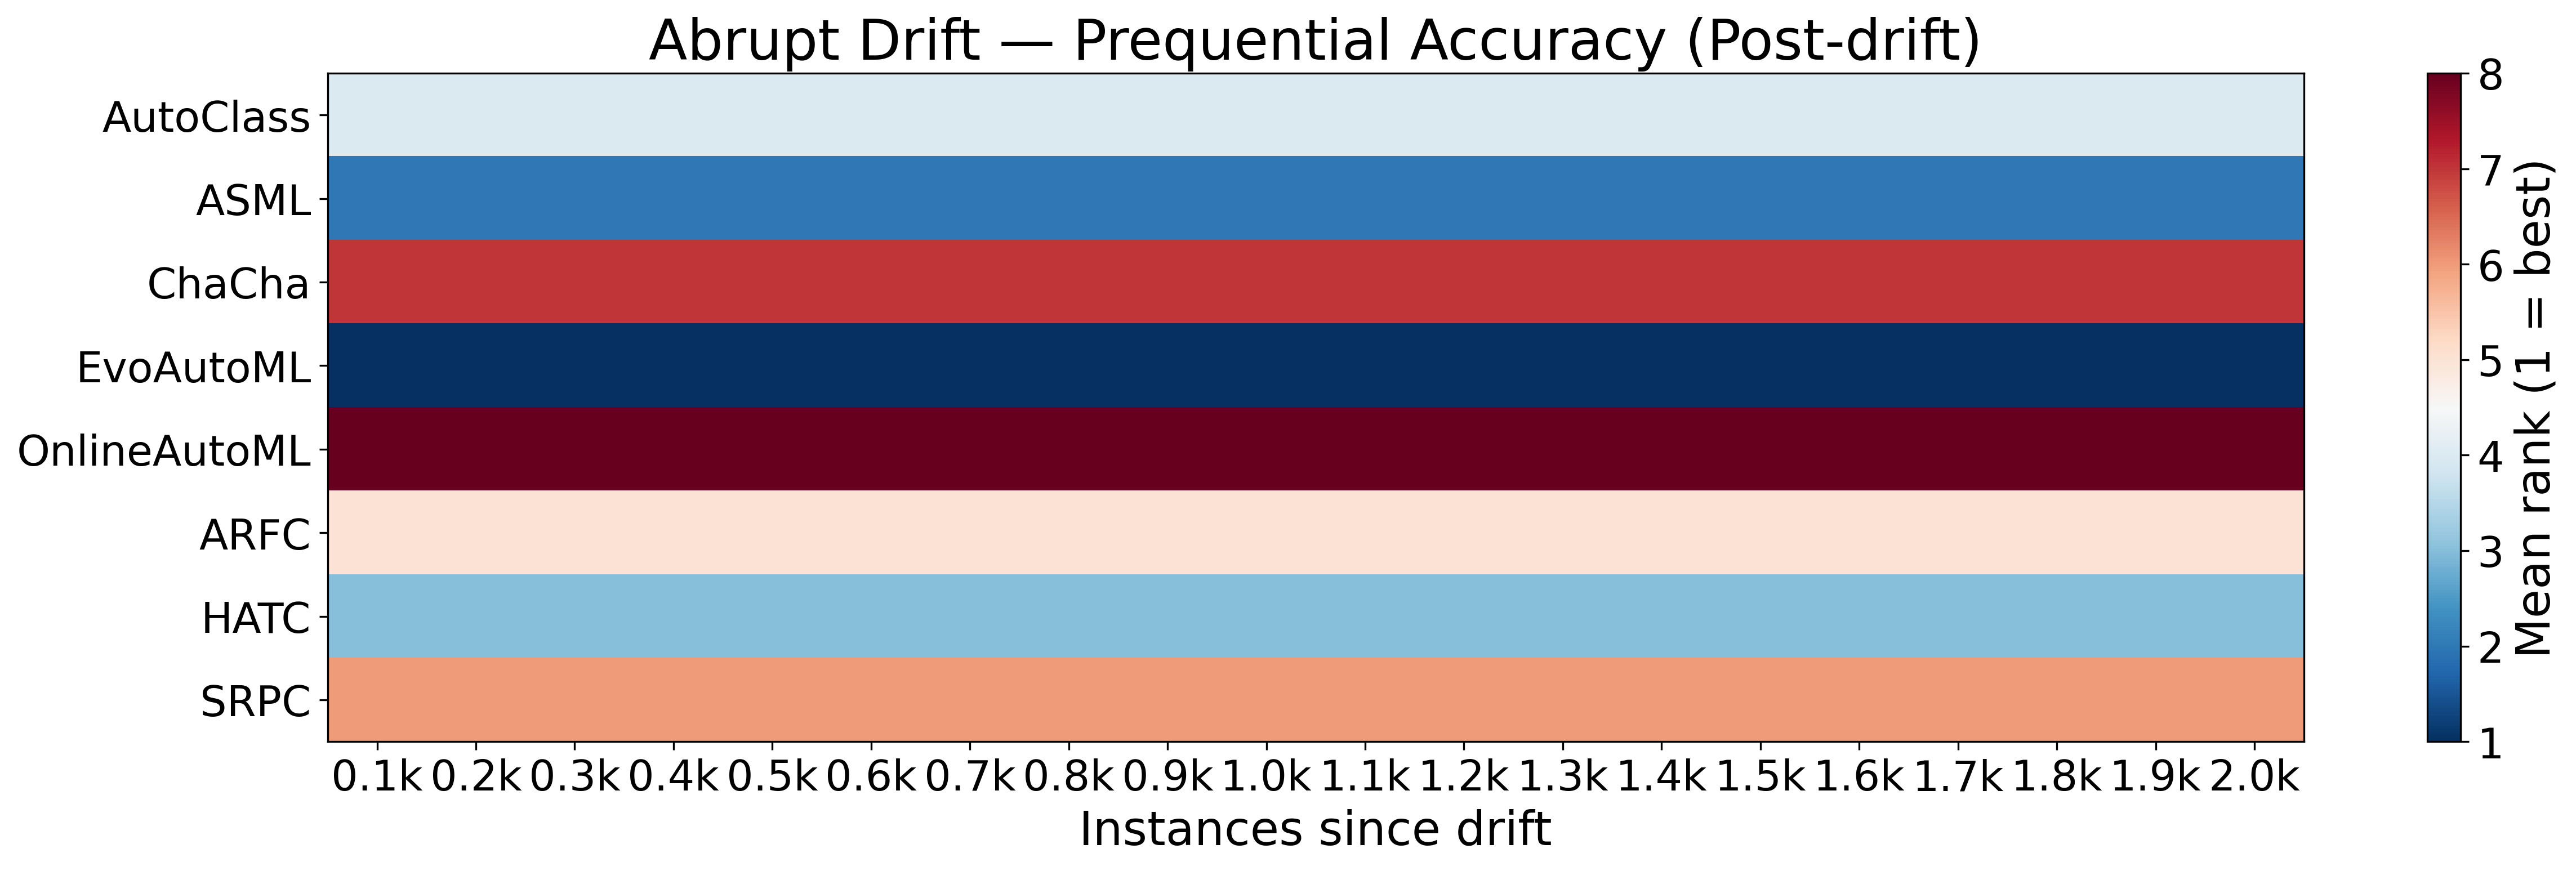

In [13]:
heatmap_a_acc = build_rank_heatmap(
    dataset_list=A_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="accuracy",    
    bin_size=100,
    window_size=50
)




plot_rank_heatmap(
    heatmap_a_acc,
    model_names,
    title="Abrupt Drift — Prequential Accuracy (Post-drift)",
    bin_size=100
)

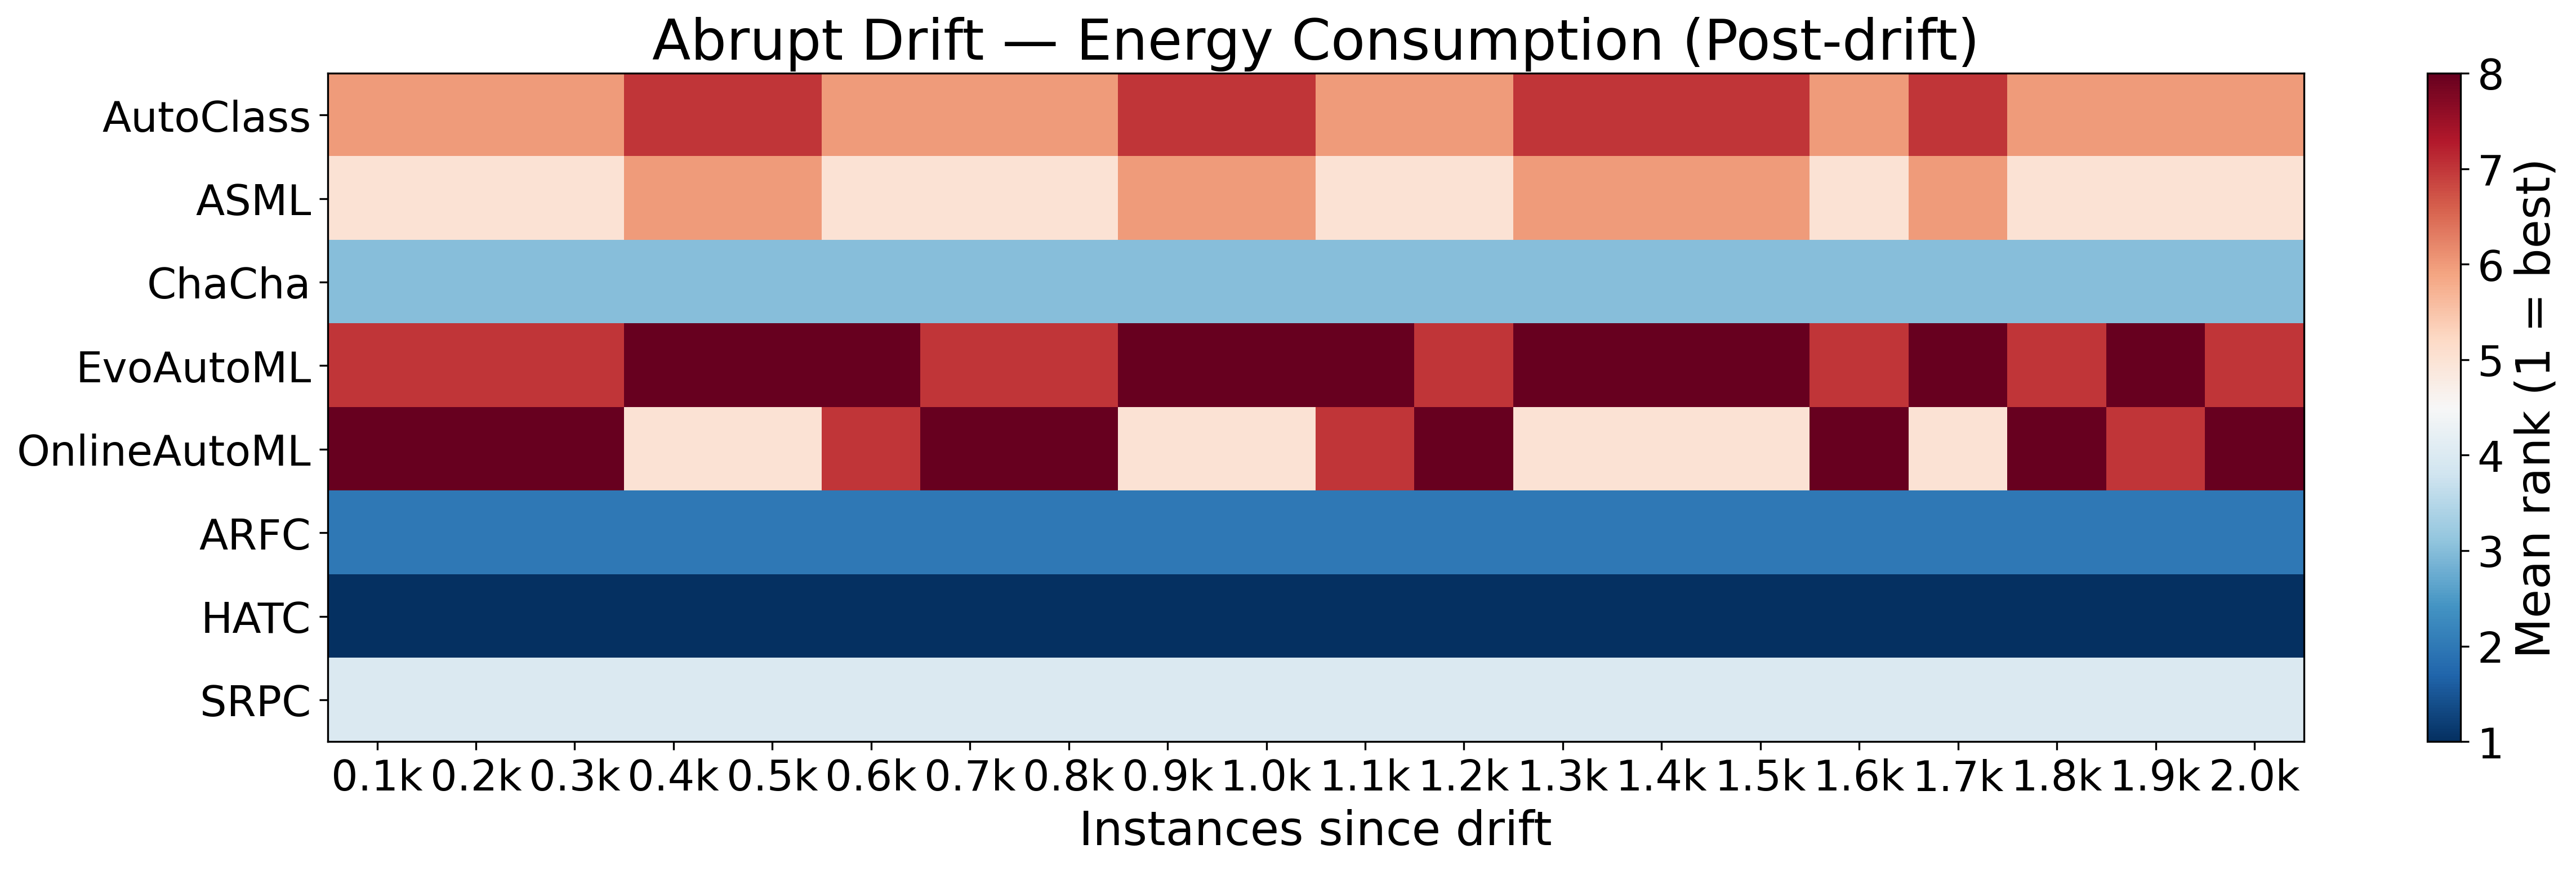

In [14]:
heatmap_a_energy = build_rank_heatmap(
    dataset_list=A_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="energy",    
    bin_size=100,
    window_size=50
)




plot_rank_heatmap(
    heatmap_a_energy,
    model_names,
    title="Abrupt Drift — Energy Consumption (Post-drift)",
    bin_size=100
)

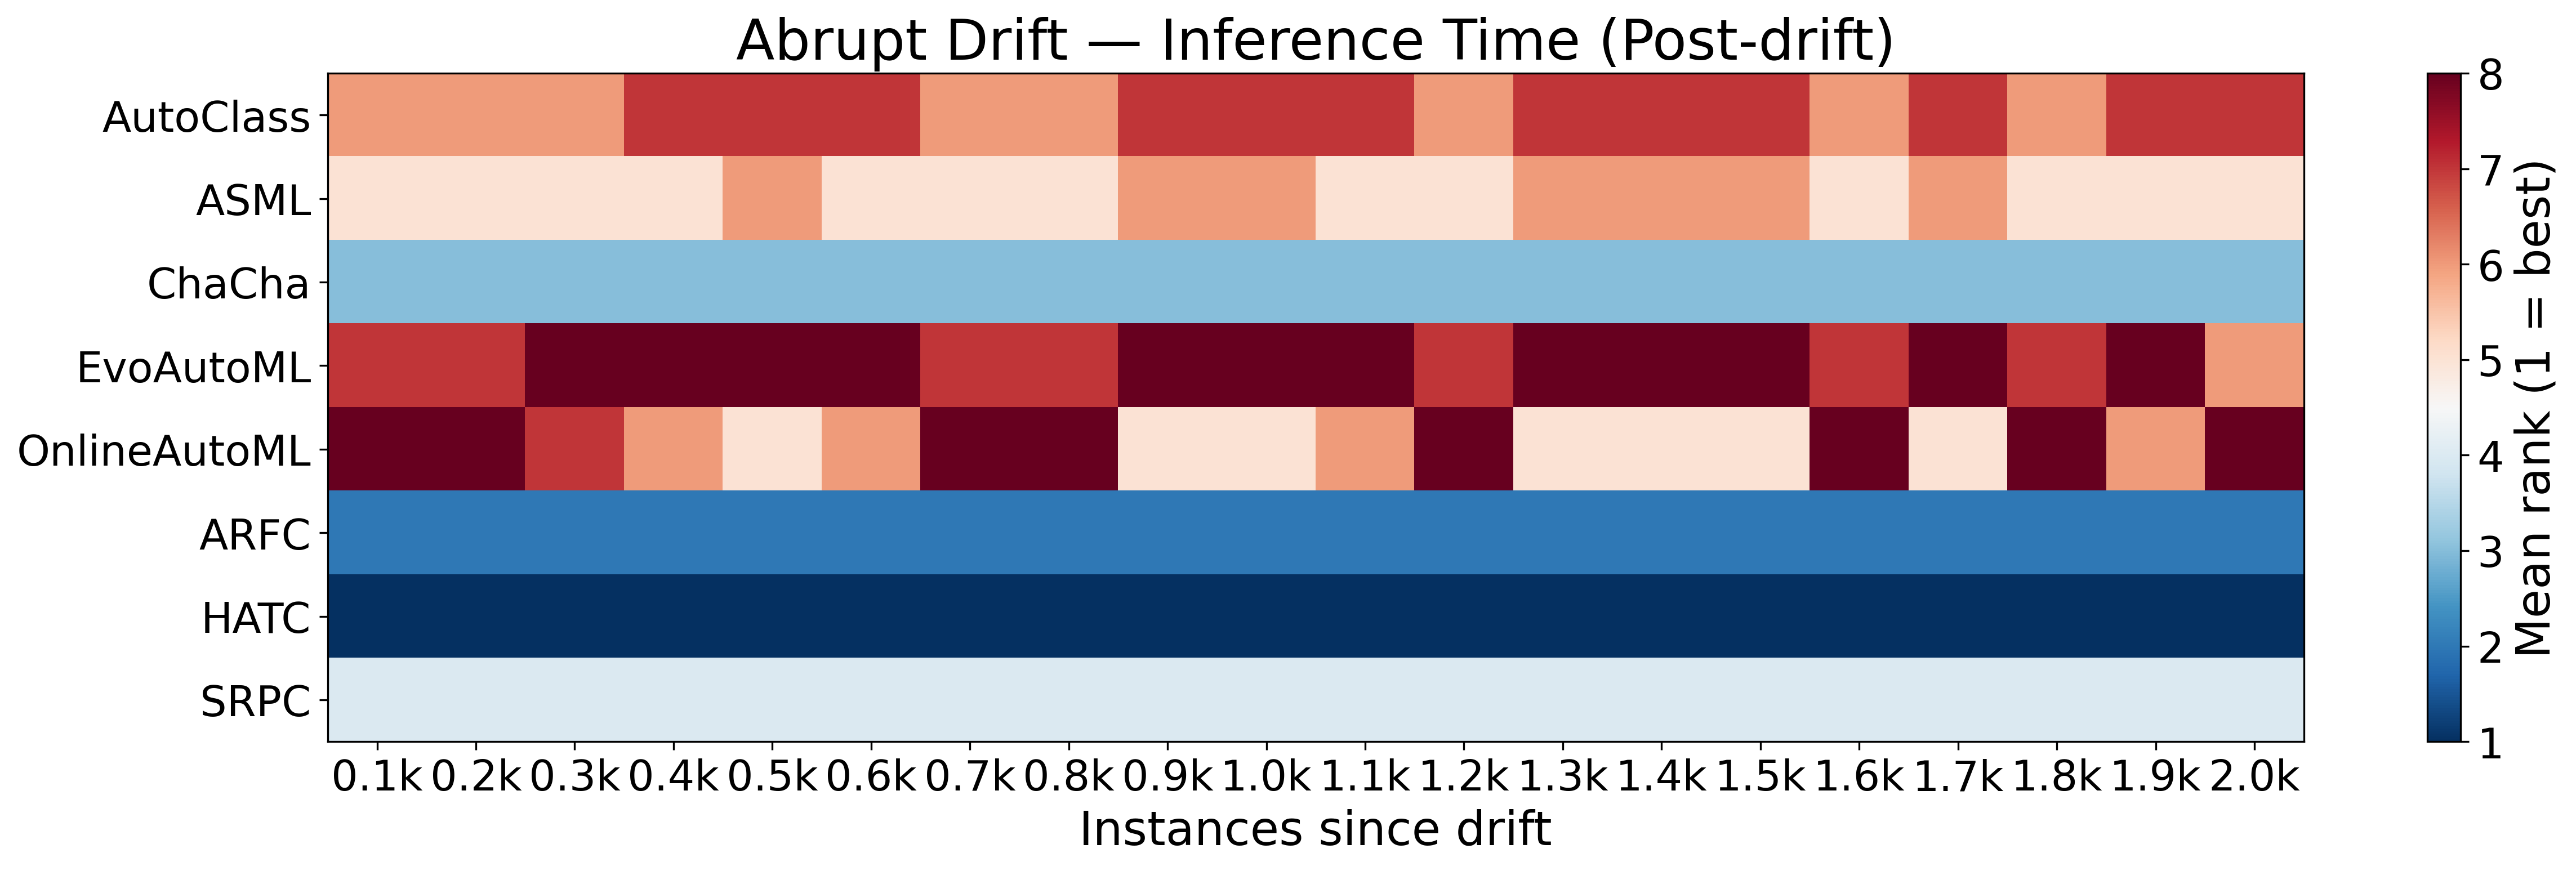

In [15]:
heatmap_a_energy = build_rank_heatmap(
    dataset_list=A_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="time",    
    bin_size=100,
    window_size=50
)




plot_rank_heatmap(
    heatmap_a_energy,
    model_names,
    title="Abrupt Drift — Inference Time (Post-drift)",
    bin_size=100
)

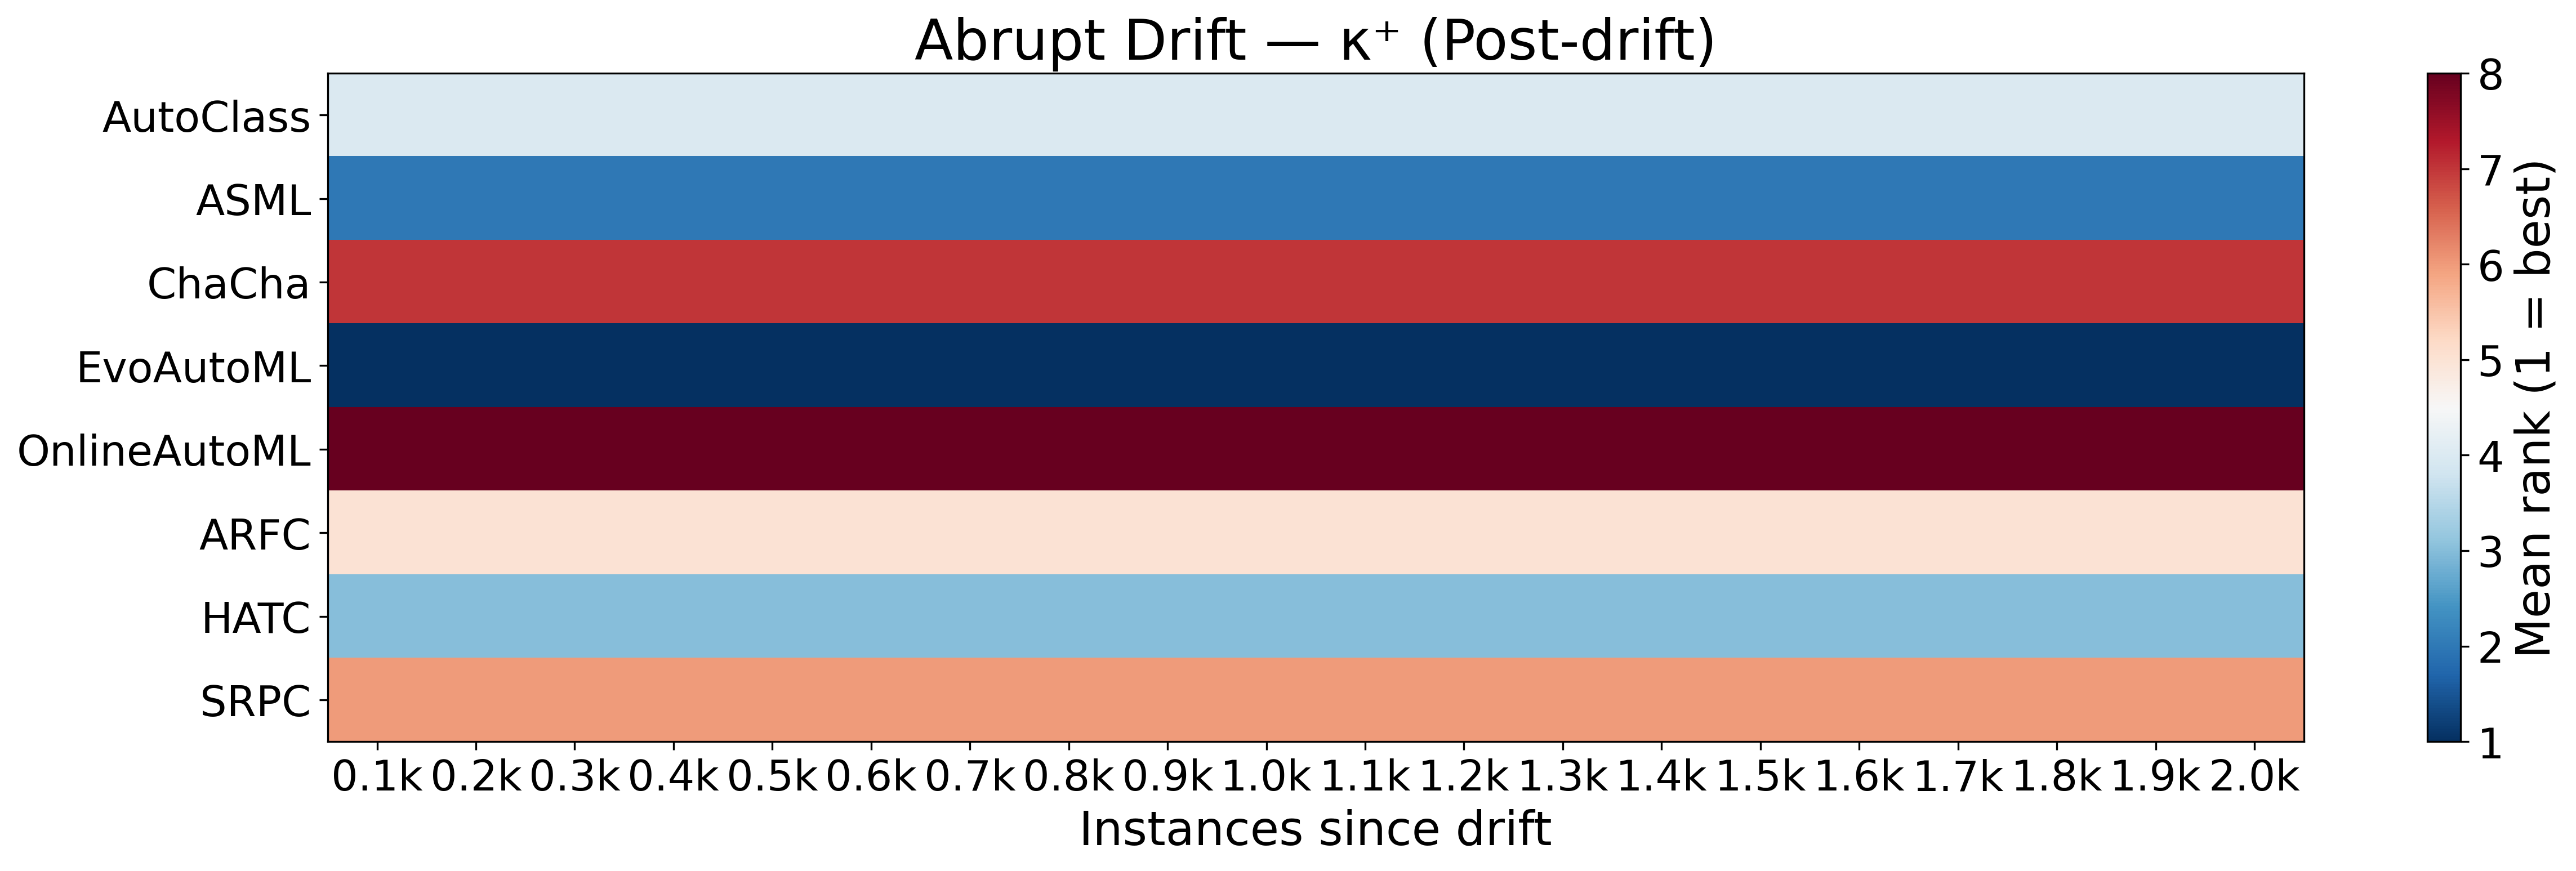

In [16]:
heatmap_a_nc = build_rank_heatmap(
    dataset_list=A_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="nc",
    bin_size=100,
    window_size=50
)

plot_rank_heatmap(
    heatmap_a_nc,
    model_names,
    title="Abrupt Drift — κ⁺ (Post-drift)",
    bin_size=100
)



In [22]:
def build_rank_heatmap(
    dataset_list,
    model_names,
    dataset_by_model,
    kappa_type="nc",
    bin_size=1000,
    max_bins=18,
    window_size=1000,
    default_config=True
):
    n_models = len(model_names)
    model_idx = {m: i for i, m in enumerate(model_names)}

    heatmap_bins = [
        [[] for _ in range(n_models)]
        for _ in range(max_bins)
    ]

    for dataset in dataset_list:

        real_dataset = pd.read_csv(f'stream_datasets/{dataset}.csv')
        class_values = real_dataset['class']
        dataset_len = len(class_values)

        # ---- drift handling ----
        if dataset in DRIFT_INFO:
            drift = DRIFT_INFO[dataset]
            start = drift['point'] + drift['width']
        else:
            start = 0

        threshold = int(dataset_len - window_size)
        class_values = class_values[:threshold]

        no_change_probabilities = kappa_no_chan_probs(
            window_size=window_size,
            class_values=class_values
        )
        chance_probabilities = kappa_chan_probs(
            window_size=window_size,
            class_values=class_values
        )

        for model in model_names:
            for sample in dataset_by_model[dataset][model]:

                if default_config:
                    if model=='AutoClass' and 'population_size_10_exploration_window_1000' not in sample: continue
                    if model=='AutoStreamML' and 'exploration_window_1000_ensemble_size_3_budget_10' not in sample: continue
                    if model=='EvoAutoML' and 'population_size_10_sampling_size_1_sampling_rate_1000' not in sample: continue
                    if model=='OnlineAutoML' and 'default' not in sample: continue
                    if model in ['SRPC','ARFC','HATC'] and 'nmodel_3' not in sample: continue

                with open(sample) as f:
                    data = json.load(f)

                prequential_scores = np.array(data['prequential_scores'])
                if len(prequential_scores) < threshold:
                    continue

                prequential_scores = prequential_scores[:threshold]
                prequential_scores = downsample(prequential_scores, window_size)

                if kappa_type == "nc":
                    kappa = (
                        (prequential_scores - no_change_probabilities)
                        / (1 - no_change_probabilities)
                    )
                elif kappa_type == "ch":
                    kappa = (
                    (prequential_scores - chance_probabilities)
                    / (1 - chance_probabilities)
                )
                elif kappa_type == "accuracy":
                    kappa = prequential_scores
                elif kappa_type == "energy":
                    metric = np.array(data["energy_consumed"])[:threshold]
                    metric = downsample(metric, window_size)
                    kappa = -metric 
                elif kappa_type == "time":
                    metric = np.array(data["energy_consumed"])[:threshold]
                    metric = downsample(metric, window_size)
                    kappa = -metric 

                x = np.arange(len(kappa)) * window_size

                for t, val in zip(x, kappa):
                    if t < start:
                        continue
                    b = int((t - start) // bin_size)
                    if b >= max_bins:
                        break
                    heatmap_bins[b][model_idx[model]].append(val)

    # ---- rank aggregation ----
    heatmap = np.full((n_models, max_bins), np.nan)

    for b in range(max_bins):
        means = np.array([
            np.mean(v) if len(v) > 0 else np.nan
            for v in heatmap_bins[b]
        ])

        if np.all(np.isnan(means)):
            continue

        heatmap[:, b] = rankdata(-means, method="average")

    return heatmap


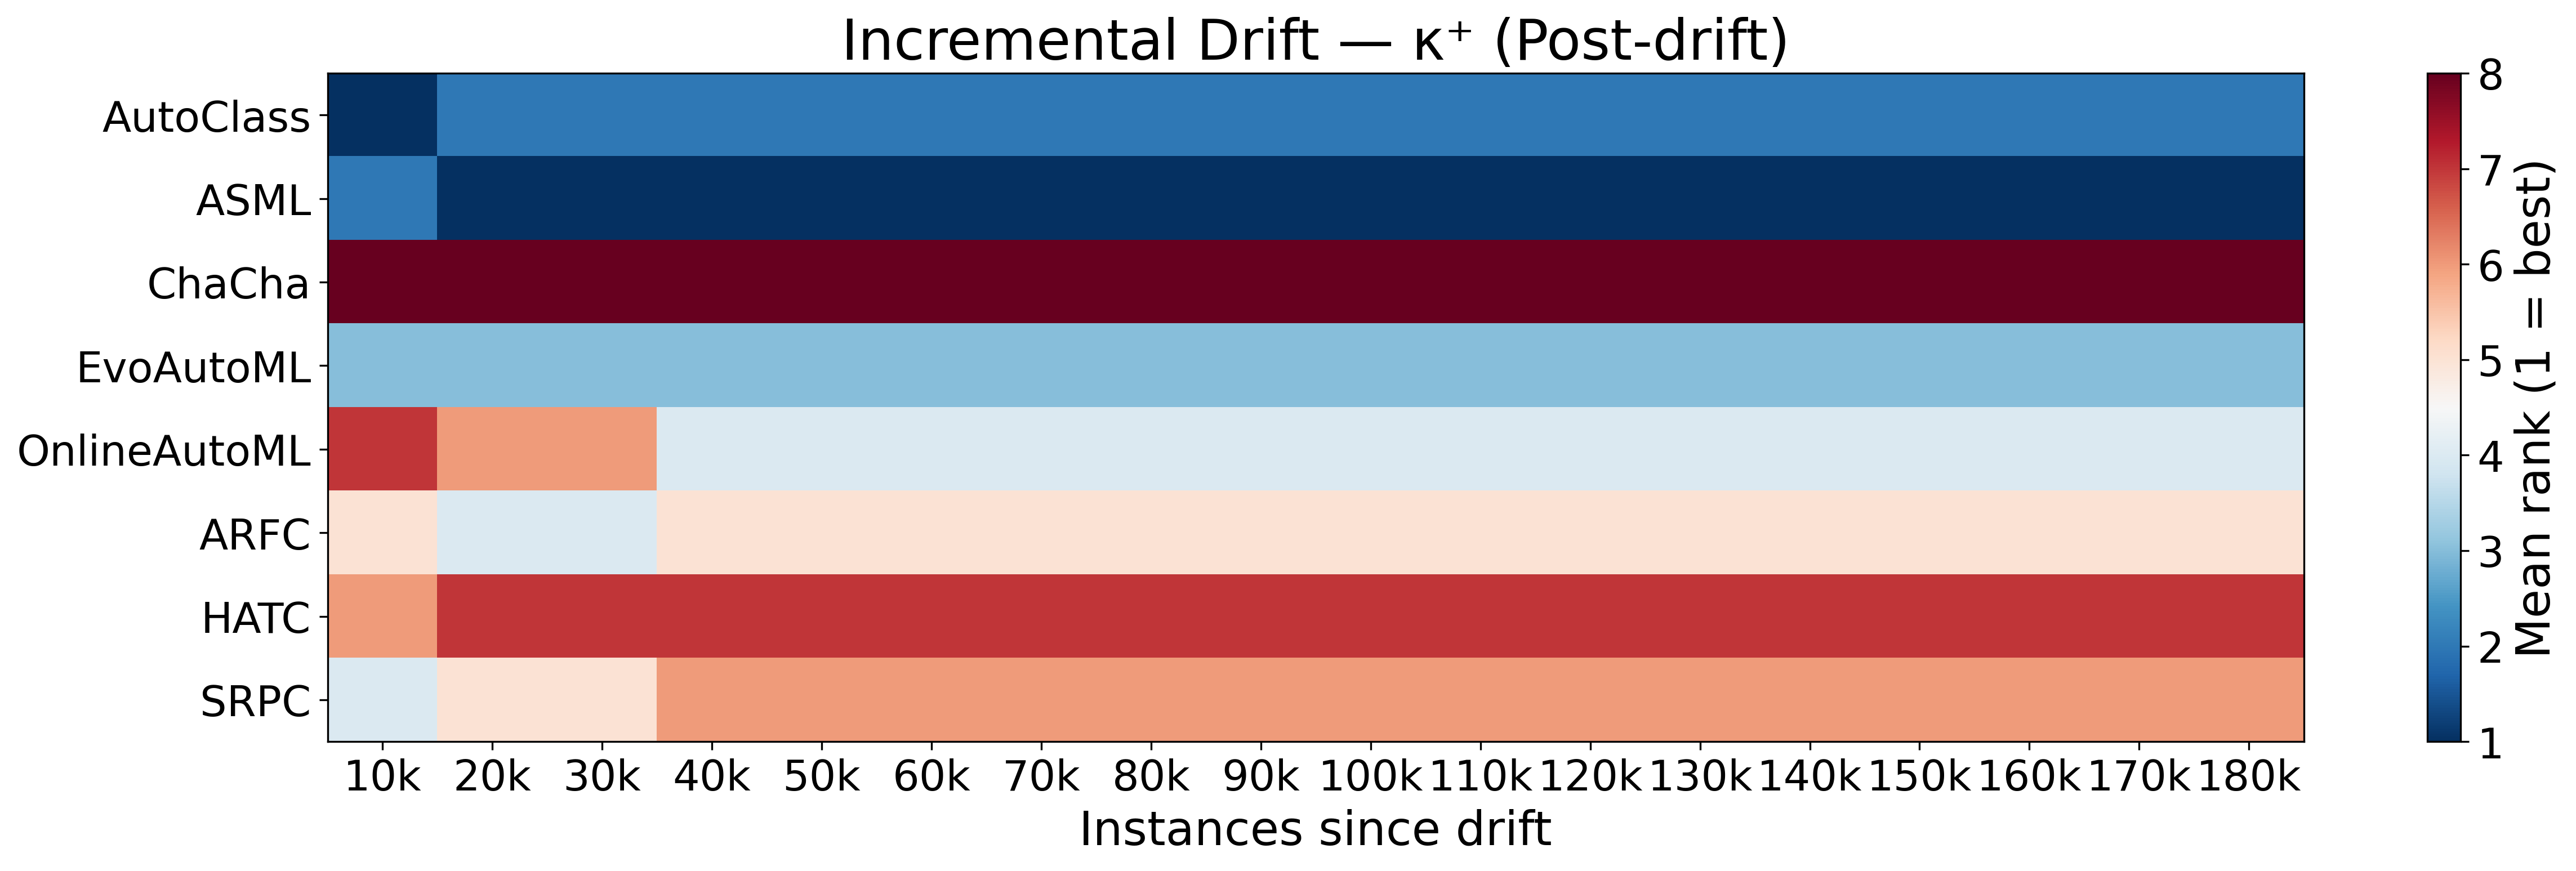

In [18]:
heatmap_i_nc = build_rank_heatmap(
    dataset_list=I_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="nc",
    bin_size=10000,
    window_size=10000
)

plot_rank_heatmap(
    heatmap_i_nc,
    model_names,
    title="Incremental Drift — κ⁺ (Post-drift)",
    bin_size=10000
)


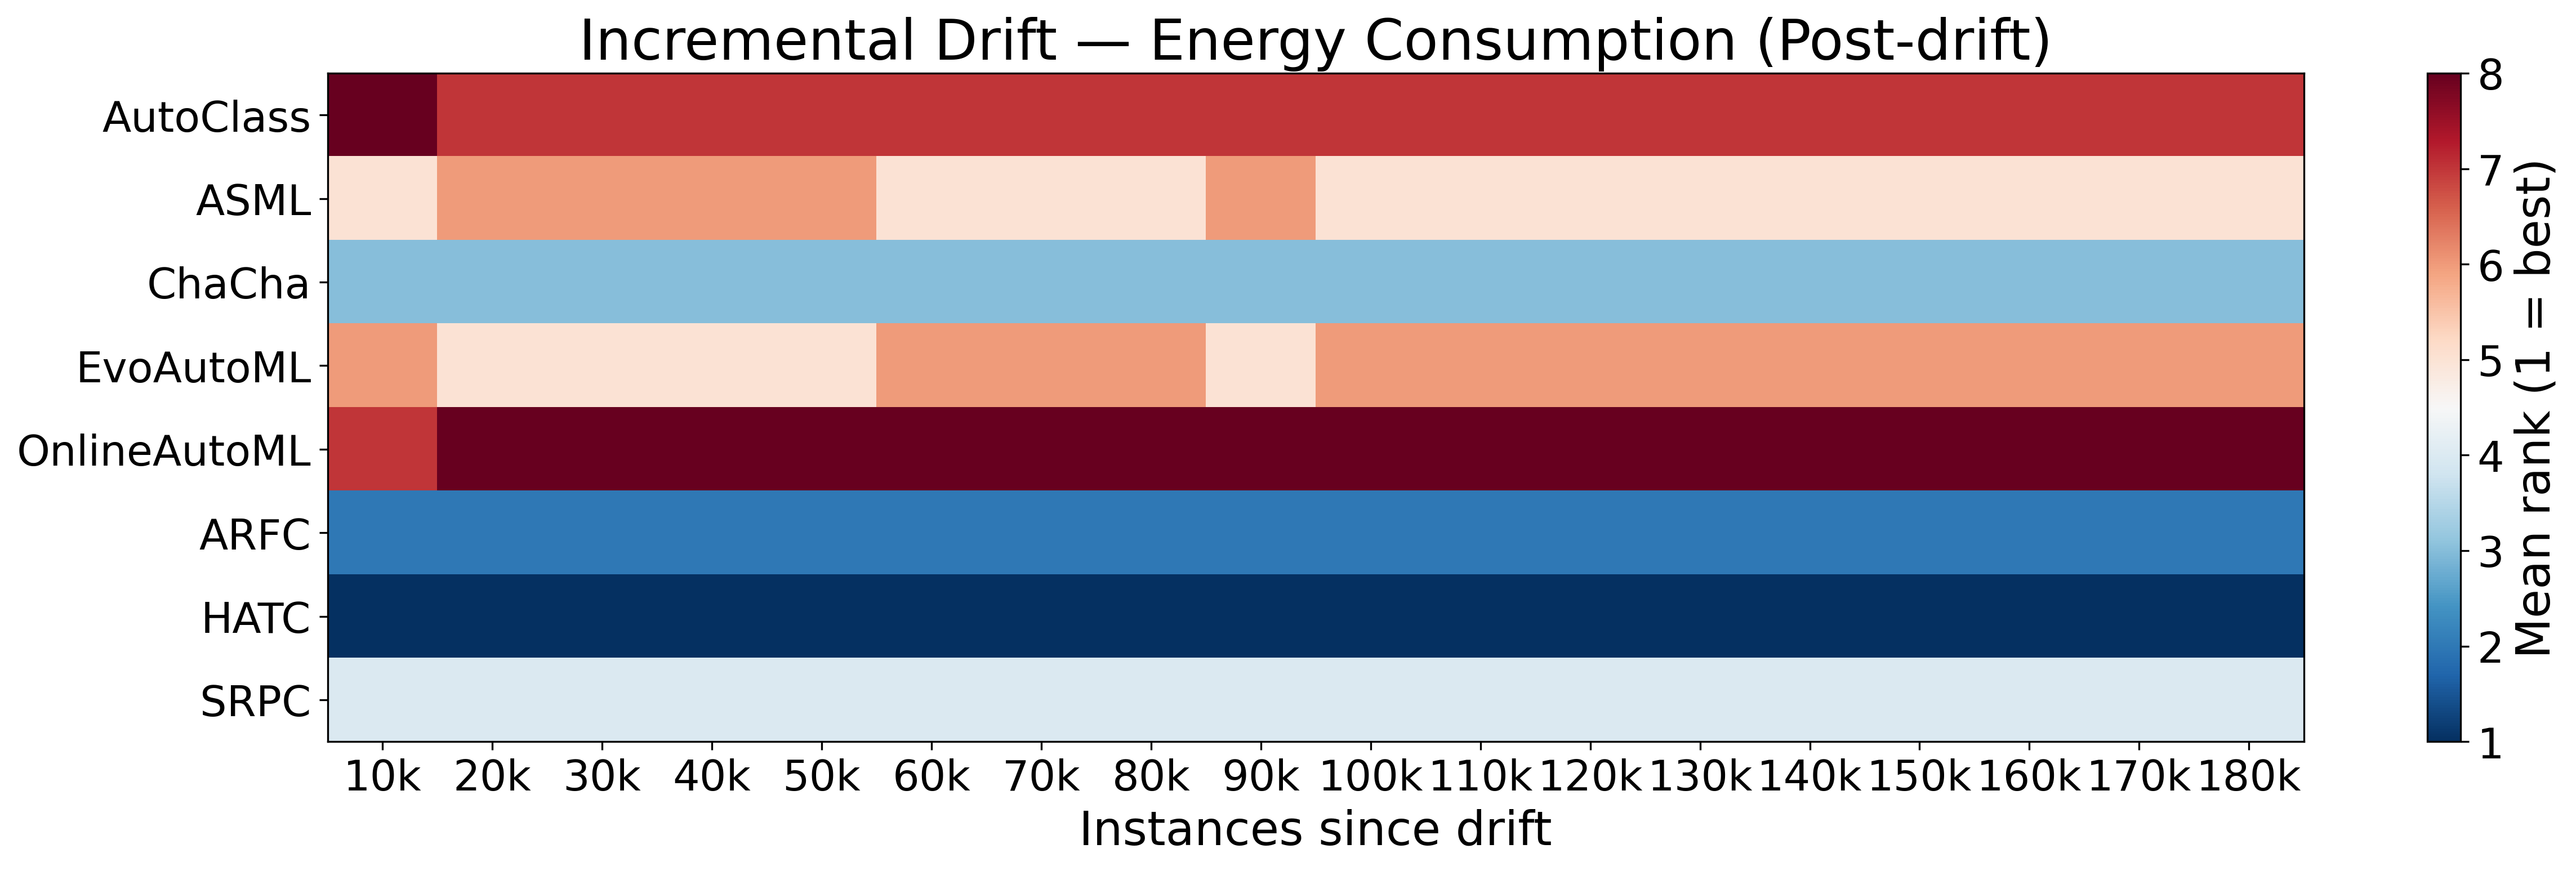

In [19]:
heatmap_i_energy = build_rank_heatmap(
    dataset_list=I_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="energy",
    bin_size=10000,
    window_size=10000
)

plot_rank_heatmap(
    heatmap_i_energy,
    model_names,
    title="Incremental Drift — Energy Consumption (Post-drift)",
    bin_size=10000
)

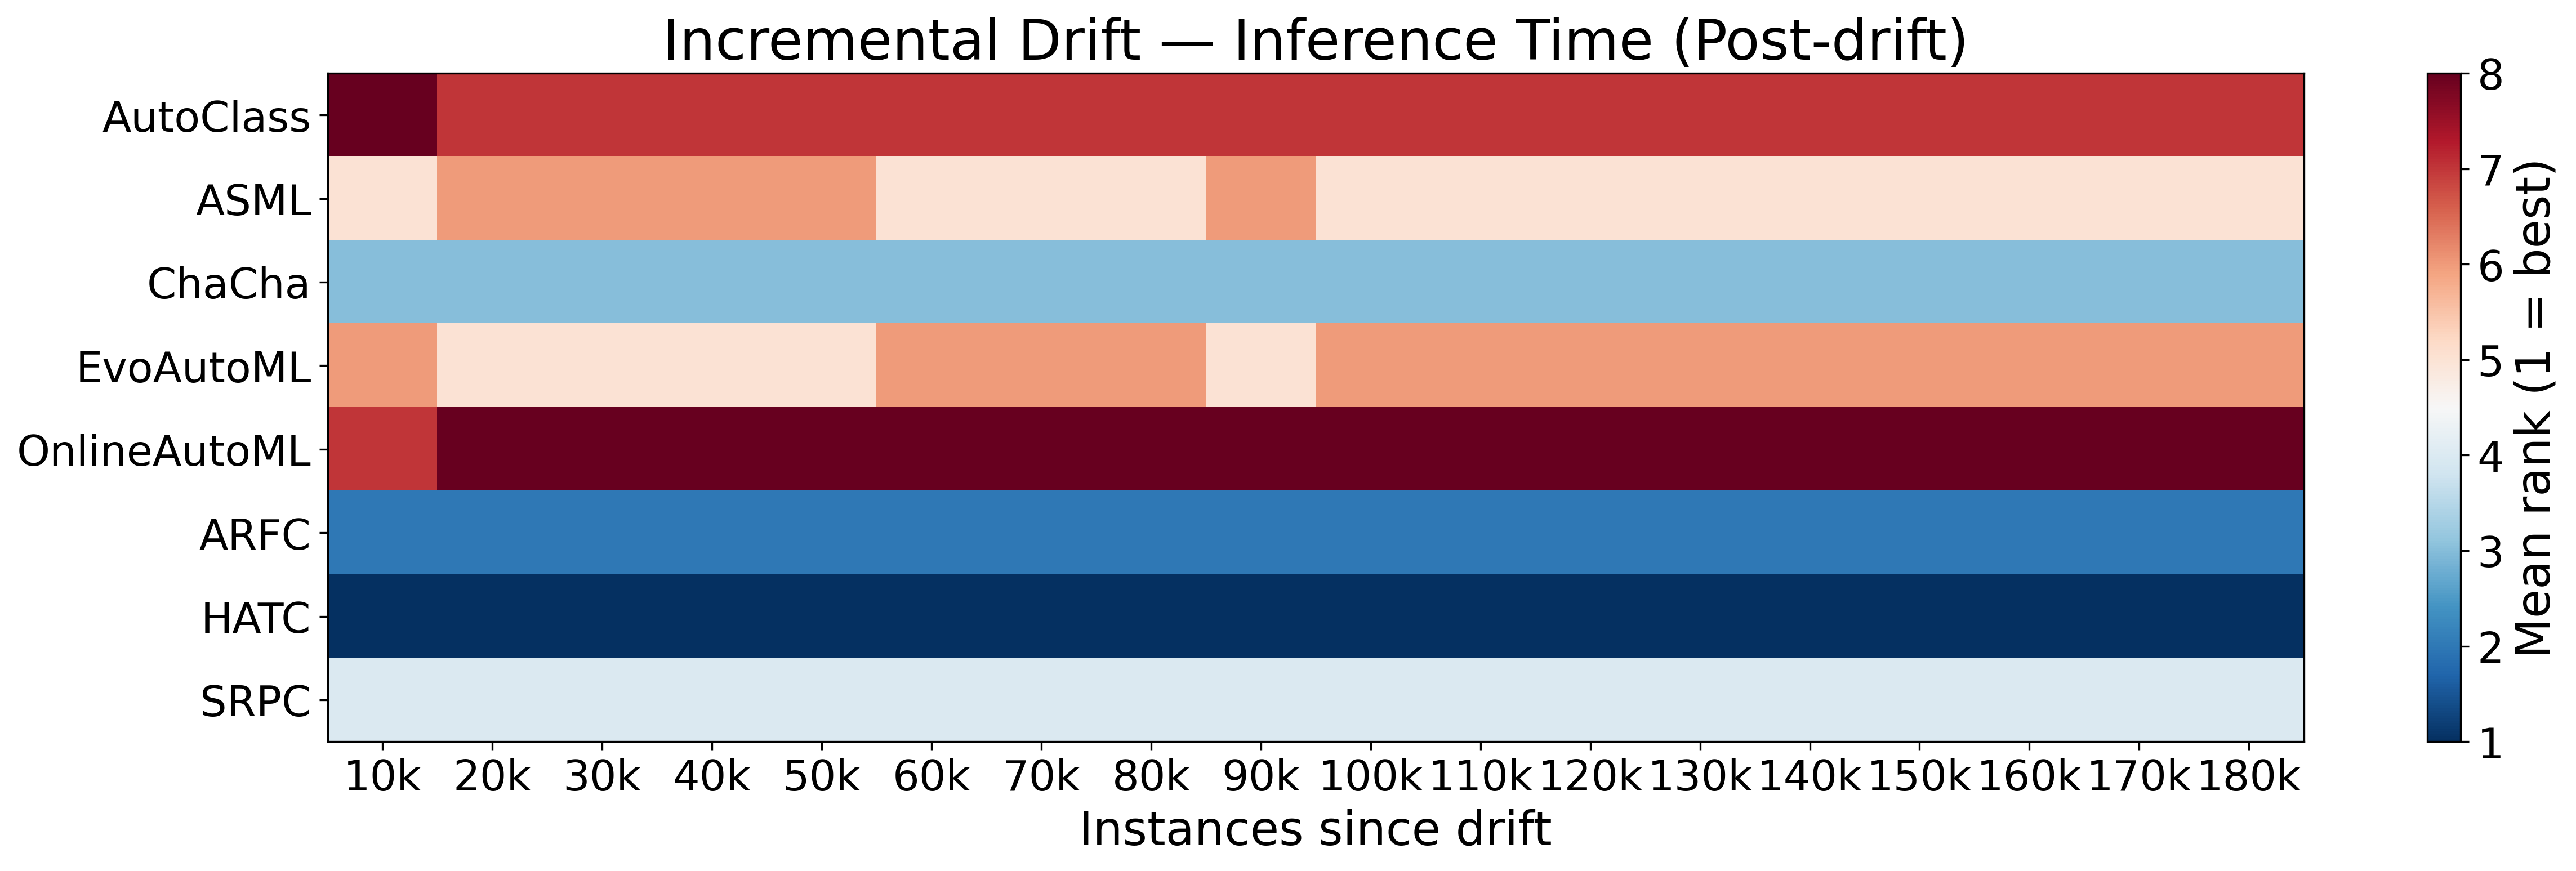

In [23]:
heatmap_i_energy = build_rank_heatmap(
    dataset_list=I_drift,
    model_names=model_names,
    dataset_by_model=dataset_by_model,
    kappa_type="time",
    bin_size=10000,
    window_size=10000
)

plot_rank_heatmap(
    heatmap_i_energy,
    model_names,
    title="Incremental Drift — Inference Time (Post-drift)",
    bin_size=10000
)